In [1]:
import pandas as pd

# Load datasets
df_ar = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/event_study_abnormal_returns_panel_10_20_v2.csv")
df_reg = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/full_event_regimes.csv")

In [2]:
df_ar.head()

,event_id,ticker,date,event_day,abnormal_return
0,AAPL_2005-07-13,AAPL,2005-07-05,-8,0.026191
1,AAPL_2005-07-13,AAPL,2005-07-06,-7,-0.006099
2,AAPL_2005-07-13,AAPL,2005-07-07,-6,-0.006843
3,AAPL_2005-07-13,AAPL,2005-07-08,-5,-0.011699
4,AAPL_2005-07-13,AAPL,2005-07-11,-2,-0.027788


In [3]:
df_reg.head()

,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol,totalRevenue,grossProfit,...,event_id,ticker,revenue_growth,margin_trend,profitability,revenue_growth_regime,eps_surprise_regime,profitability_regime,margin_trend_regime,financial_strength_regime
0,2005-09-30,2005-10-11,0.01,0.01,0.0,0.0,post-market,AAPL,3678000000,1035000000,...,AAPL_2005-09-30,AAPL,NaN,NaN,0.113649,missing,small,medium,missing,mixed
1,2005-12-31,2006-01-18,0.02,0.02,0.0,0.0,post-market,AAPL,5749000000,1564000000,...,AAPL_2005-12-31,AAPL,0.563078,-0.018633,0.130457,high_growth,small,medium,contraction,mixed
2,2006-03-31,2006-04-19,0.02,0.02,0.0,0.0,post-market,AAPL,4359000000,1297000000,...,AAPL_2006-03-31,AAPL,-0.241781,-0.004220,0.121358,negative_growth,small,medium,stable,mixed
3,2006-06-30,2006-07-19,0.02,0.02,0.0,0.0,post-market,AAPL,4370000000,1325000000,...,AAPL_2006-06-30,AAPL,0.002524,0.013951,0.129519,moderate_growth,small,medium,expansion,mixed
4,2006-09-30,2006-10-18,0.02,0.02,0.0,0.0,post-market,AAPL,4370000000,1412000000,...,AAPL_2006-09-30,AAPL,0.000000,0.016018,0.139130,moderate_growth,small,medium,expansion,mixed


In [4]:
# Ensure reportedDate is datetime
df_reg["reportedDate"] = pd.to_datetime(df_reg["reportedDate"], errors="coerce")

# Build event_id that matches your corrected event-study panel (ticker + reportedDate)
df_reg["event_id_reported"] = (
    df_reg["ticker"].astype(str) + "_" + df_reg["reportedDate"].dt.strftime("%Y-%m-%d")
)

In [5]:
# Compute CAR windows for each event
def compute_car(df_ar, t1, t2, label):
    car = (
        df_ar[(df_ar["event_day"] >= t1) & (df_ar["event_day"] <= t2)]
        .groupby("event_id")["abnormal_return"]
        .sum()
        .reset_index()
        .rename(columns={"abnormal_return": label})
    )
    return car

car_m1_p1 = compute_car(df_ar, -1, 1, "CAR_m1_p1")
car_m2_p2 = compute_car(df_ar, -2, 2, "CAR_m2_p2")
car_m5_p5 = compute_car(df_ar, -5, 5, "CAR_m5_p5")

In [6]:
# Merge CAR windows into the event‑level dataset 
df = df_reg.copy()

df = df.merge(
    car_m1_p1,
    left_on="event_id_reported",
    right_on="event_id",
    how="left"
).drop(columns=["event_id"], errors="ignore")

df = df.merge(
    car_m2_p2,
    left_on="event_id_reported",
    right_on="event_id",
    how="left"
).drop(columns=["event_id"], errors="ignore")

df = df.merge(
    car_m5_p5,
    left_on="event_id_reported",
    right_on="event_id",
    how="left"
).drop(columns=["event_id"], errors="ignore")

In [7]:
# Add EPS‑surprise binary variable
df["eps_bin2"] = (df["surprise"] > 0).astype(int)

In [8]:
# Split the dataset by company
companies = ["AAPL", "GOOGL", "NVDA"]
company_data = {c: df[df["ticker"] == c].copy() for c in companies}


In [9]:
# Company‑level regressions (AR and CAR windows)
import statsmodels.api as sm

def run_regression(df, y_col):
    X = sm.add_constant(df[["eps_bin2"]])
    y = df[y_col]
    return sm.OLS(y, X).fit()

results = {}

for c in companies:
    d = company_data[c]
    results[c] = {
        "AR0": run_regression(d, "AR0") if "AR0" in d.columns else None,
        "CAR_m1_p1": run_regression(d, "CAR_m1_p1"),
        "CAR_m2_p2": run_regression(d, "CAR_m2_p2"),
        "CAR_m5_p5": run_regression(d, "CAR_m5_p5"),
    }


In [10]:
for c in companies:
    print(f"\n=== {c} ===")
    for k, model in results[c].items():
        if model is not None:
            print(f"\n--- {k} ---")
            print(model.summary())


=== AAPL ===

--- CAR_m1_p1 ---
                            OLS Regression Results                            
Dep. Variable:              CAR_m1_p1   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.197
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.142
Time:                        12:56:47   Log-Likelihood:                 135.52
No. Observations:                  81   AIC:                            -267.0
Df Residuals:                      79   BIC:                            -262.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.00

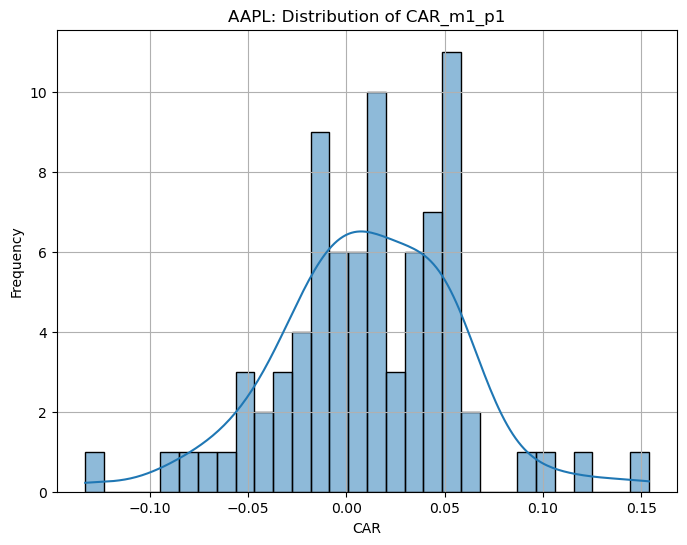

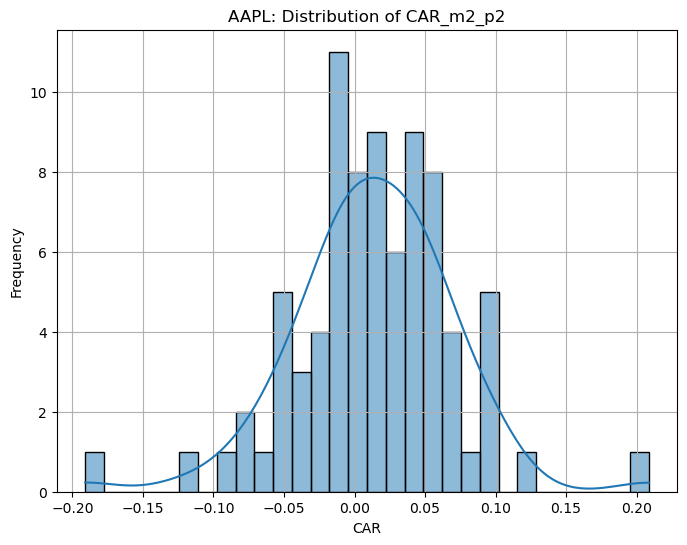

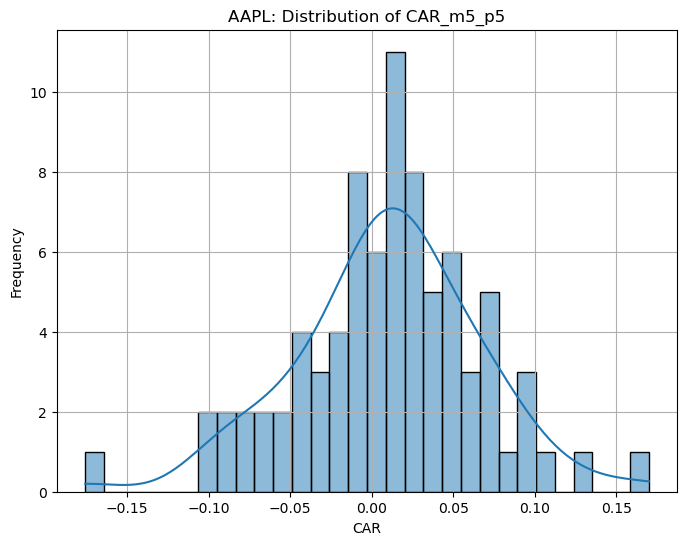

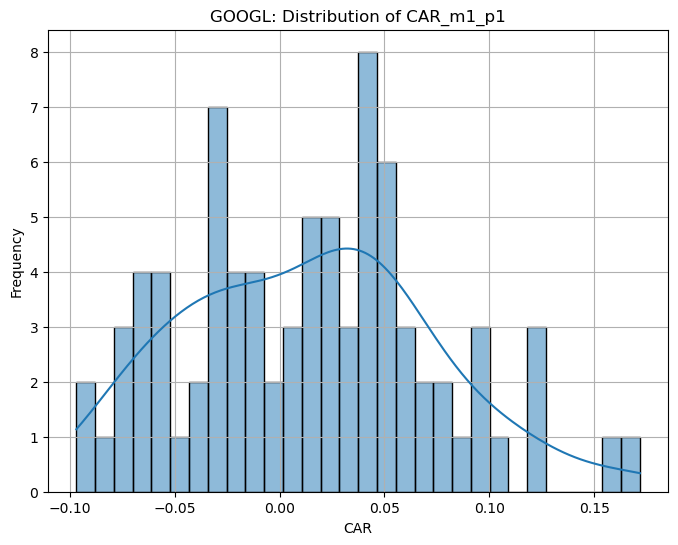

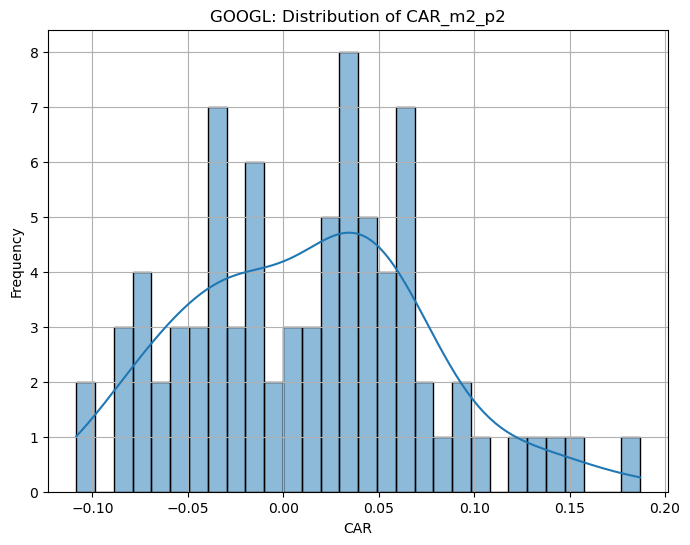

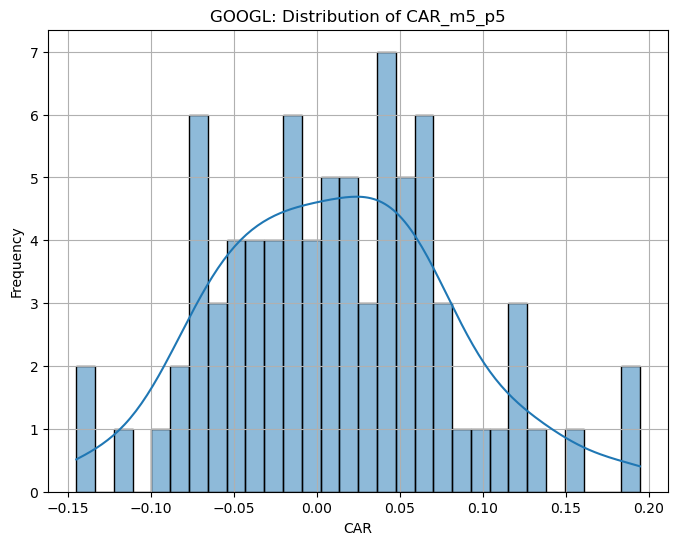

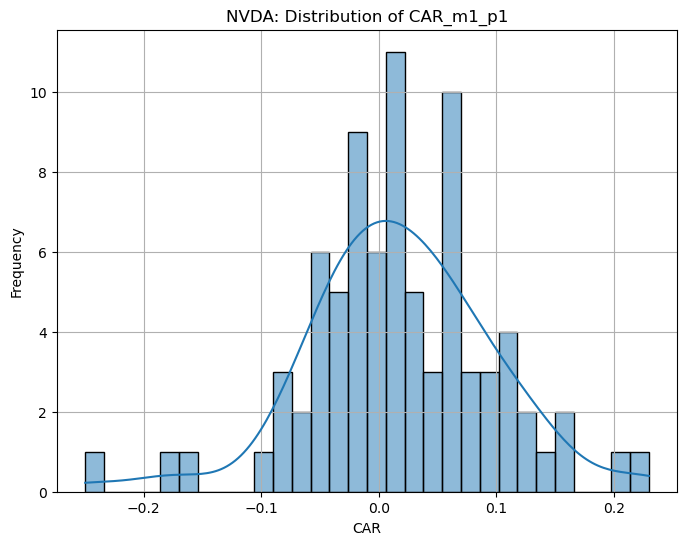

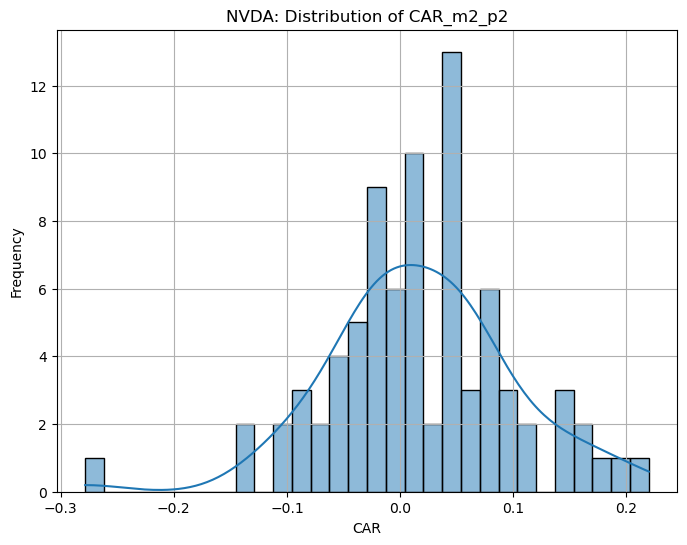

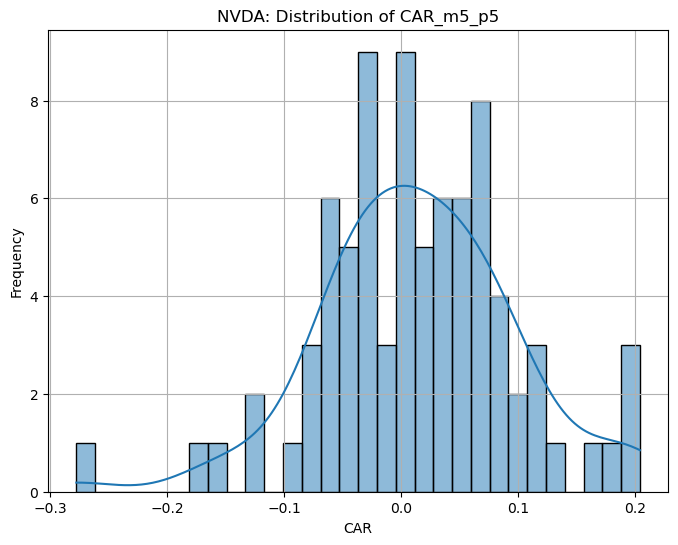

In [11]:
# Company‑specific CAR distribution plots
import seaborn as sns
import matplotlib.pyplot as plt

def plot_car_by_company(df, company, car_col):
    plt.figure(figsize=(8,6))
    sns.histplot(df[car_col], bins=30, kde=True)
    plt.title(f"{company}: Distribution of {car_col}")
    plt.xlabel("CAR")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

for c in companies:
    d = company_data[c]
    plot_car_by_company(d, c, "CAR_m1_p1")
    plot_car_by_company(d, c, "CAR_m2_p2")
    plot_car_by_company(d, c, "CAR_m5_p5")

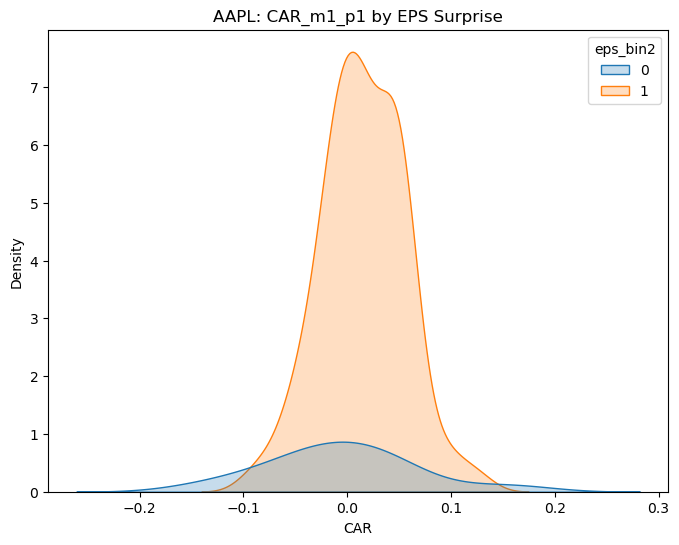

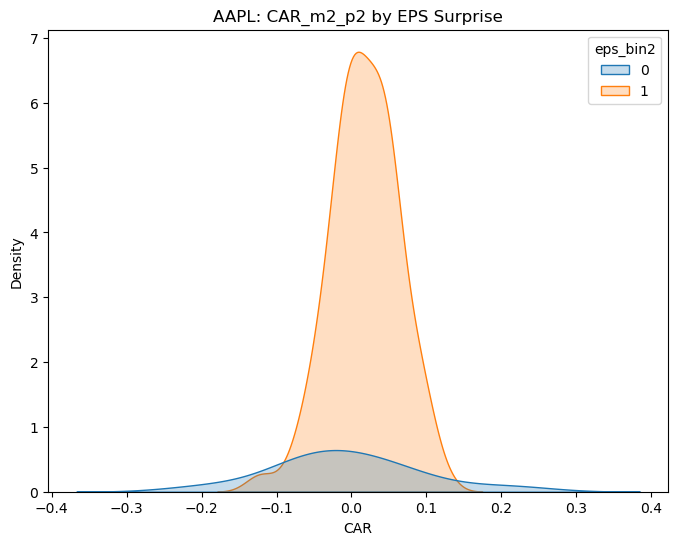

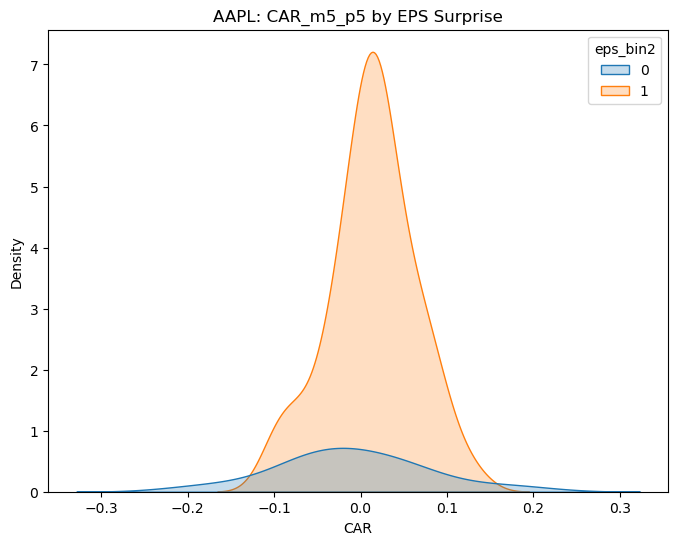

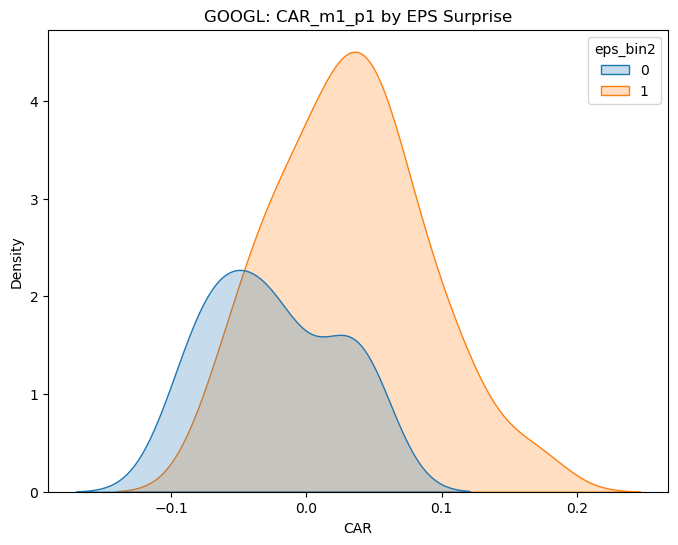

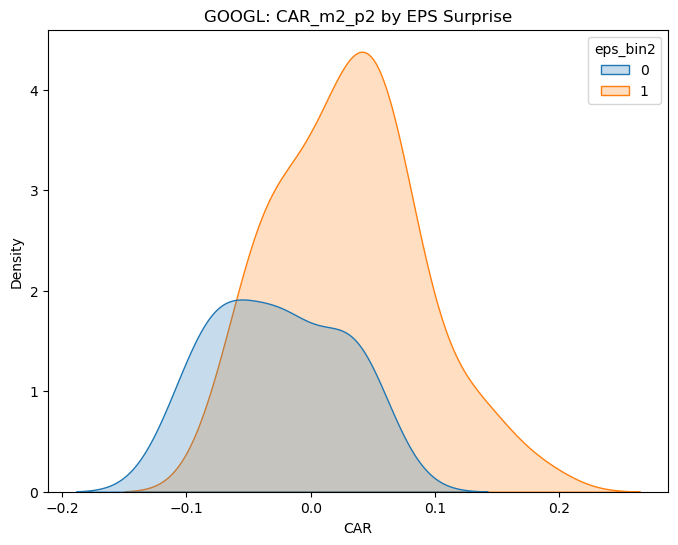

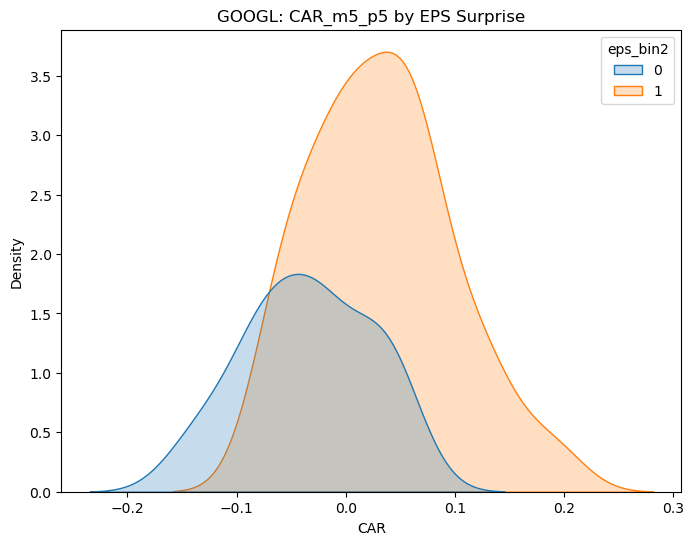

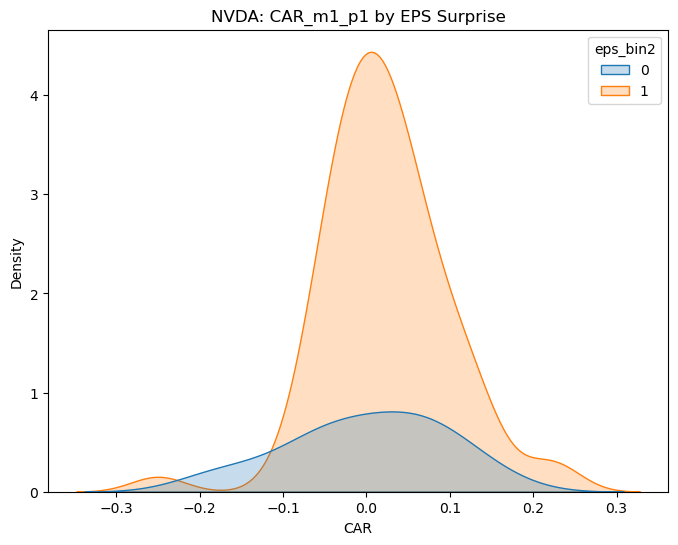

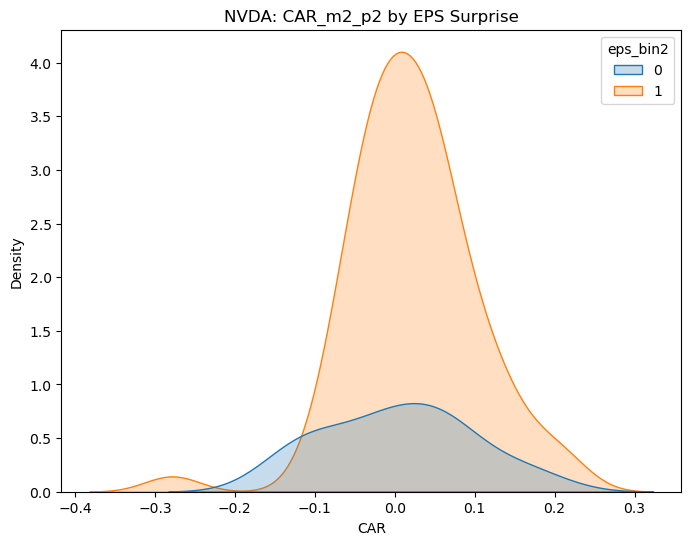

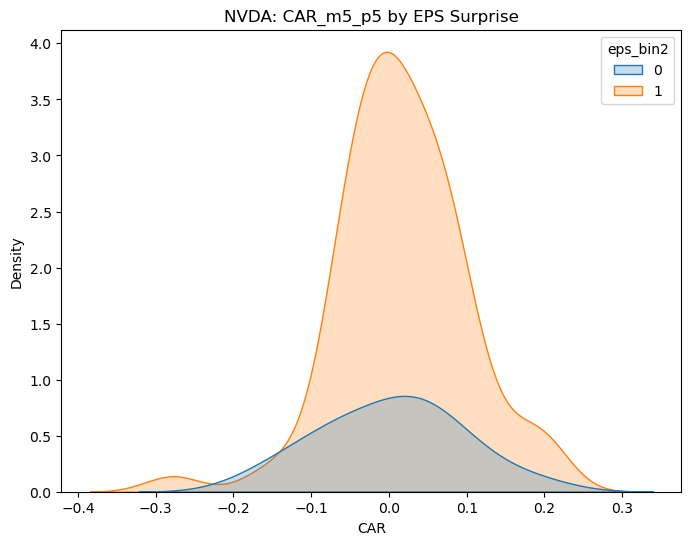

In [12]:
# Company‑specific CAR by EPS‑surprise plots
def plot_car_eps(df, company, car_col):
    plt.figure(figsize=(8,6))
    sns.kdeplot(data=df, x=car_col, hue="eps_bin2", fill=True)
    plt.title(f"{company}: {car_col} by EPS Surprise")
    plt.xlabel("CAR")
    plt.ylabel("Density")
    plt.show()

for c in companies:
    d = company_data[c]
    plot_car_eps(d, c, "CAR_m1_p1")
    plot_car_eps(d, c, "CAR_m2_p2")
    plot_car_eps(d, c, "CAR_m5_p5")


In [13]:
df.columns

Index(['fiscalDateEnding', 'reportedDate', 'reportedEPS', 'estimatedEPS',
       'surprise', 'surprisePercentage', 'reportTime', 'symbol',
       'totalRevenue', 'grossProfit', 'operatingIncome', 'netIncome',
       'grossMargin', 'operatingMargin', 'netMargin', 'event_id_x', 'ticker',
       'revenue_growth', 'margin_trend', 'profitability',
       'revenue_growth_regime', 'eps_surprise_regime', 'profitability_regime',
       'margin_trend_regime', 'financial_strength_regime', 'event_id_reported',
       'event_id_y', 'CAR_m1_p1', 'CAR_m2_p2', 'CAR_m5_p5', 'eps_bin2'],
      dtype='object')

In [16]:
df["ticker"].value_counts()

ticker
AAPL     81
GOOGL    81
NVDA     81
Name: count, dtype: int64

In [17]:
import numpy as np

# List of the four fundamental regime dimensions
metrics = [
    "profitability_regime",
    "margin_trend_regime",
    "revenue_growth_regime",
    "financial_strength_regime"
]

# CAR windows used to measure short‑drift reactions
car_cols = ["CAR_m1_p1", "CAR_m2_p2", "CAR_m5_p5"]

# Dictionary to store sensitivity results for each company
sensitivity = {}

# Loop through each company
for company in ["AAPL", "GOOGL", "NVDA"]:
    
    print("\n==============================")
    print("Company:", company)
    print("==============================")
    
    # Filter dataset to the selected company
    df_c = df[df["ticker"] == company]
    
    # Create nested dictionary for this company
    sensitivity[company] = {}
    
    # Loop through each financial‑metric regime
    for metric in metrics:
        
        print(f"\n--- Metric: {metric} ---")
        
        # Group CAR windows by regime and compute summary statistics
        stats = (
            df_c.groupby(metric)[car_cols]
            .agg(["mean", "std", "median"])   # sensitivity profile for each regime
        )
        
        # Print the table for inspection
        print(stats)
        
        # Store results in the dictionary
        sensitivity[company][metric] = stats


Company: AAPL

--- Metric: profitability_regime ---
                     CAR_m1_p1                     CAR_m2_p2            \
                          mean       std    median      mean       std   
profitability_regime                                                     
high                  0.006119  0.040068  0.005770  0.004230  0.045142   
medium                0.024263  0.057562  0.038045  0.034318  0.074281   

                               CAR_m5_p5                      
                        median      mean       std    median  
profitability_regime                                          
high                  0.002800  0.003165  0.048374  0.000585  
medium                0.045993  0.024604  0.071603  0.037001  

--- Metric: margin_trend_regime ---
                    CAR_m1_p1                     CAR_m2_p2            \
                         mean       std    median      mean       std   
margin_trend_regime                                                     
contr

In [18]:
# Function to compute a simple sensitivity score
# The score = difference between the highest and lowest mean CAR across regimes
def sensitivity_score(stats):
    # Extract mean CAR for the CAR_m1_p1 window and compute max - min
    diffs = stats["CAR_m1_p1"]["mean"].max() - stats["CAR_m1_p1"]["mean"].min()
    return diffs

# Loop through each company and compute sensitivity scores for all metrics
for company in ["AAPL", "GOOGL", "NVDA"]:
    
    print("\n", company)
    
    scores = {}   # store sensitivity scores for this company
    
    for metric in metrics:
        
        # Retrieve the previously computed stats table for this metric
        stats = sensitivity[company][metric]
        
        # Compute the sensitivity score
        scores[metric] = sensitivity_score(stats)
    
    # Print all scores for this company
    print(scores)


 AAPL
{'profitability_regime': 0.01814417264920795, 'margin_trend_regime': 0.02414050898574737, 'revenue_growth_regime': 0.029629550950649255, 'financial_strength_regime': 0.013422259276757885}

 GOOGL
{'profitability_regime': 0.053133635208109445, 'margin_trend_regime': 0.11029729558774637, 'revenue_growth_regime': 0.10315720063783117, 'financial_strength_regime': 0.044869234333240374}

 NVDA
{'profitability_regime': 0.0055571461116785854, 'margin_trend_regime': 0.09425800535592903, 'revenue_growth_regime': 0.05012291407546256, 'financial_strength_regime': 0.07566882609499259}


Apple’s and Google's CAR shifts the most when revenue growth regime changes.
NVIDIA is the only company where margin trend beats revenue growth.


In [21]:
# Pre‑computed sensitivity scores for each company and each financial‑metric regime
sensitivity_scores = {
    "AAPL": {
        "profitability_regime": 0.01814417264920795,
        "margin_trend_regime": 0.02414050898574737,
        "revenue_growth_regime": 0.029629550950649255,
        "financial_strength_regime": 0.013422259276757885
    },
    "GOOGL": {
        "profitability_regime": 0.053133635208109445,
        "margin_trend_regime": 0.11029729558774637,
        "revenue_growth_regime": 0.10315720063783117,
        "financial_strength_regime": 0.044869234333240374
    },
    "NVDA": {
        "profitability_regime": 0.0055571461116785854,
        "margin_trend_regime": 0.09425800535592903,
        "revenue_growth_regime": 0.05012291407546256,
        "financial_strength_regime": 0.07566882609499259
    }
}

# Identify the regime with the highest sensitivity score for each company
top_metric = {
    company: max(scores, key=scores.get)   # pick the regime with the largest score
    for company, scores in sensitivity_scores.items()
}

# Display the strongest driver of CAR sensitivity for each company
top_metric

{'AAPL': 'revenue_growth_regime',
 'GOOGL': 'margin_trend_regime',
 'NVDA': 'margin_trend_regime'}

C:\Users\User\AppData\Local\Temp\ipykernel_19400\1945884928.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


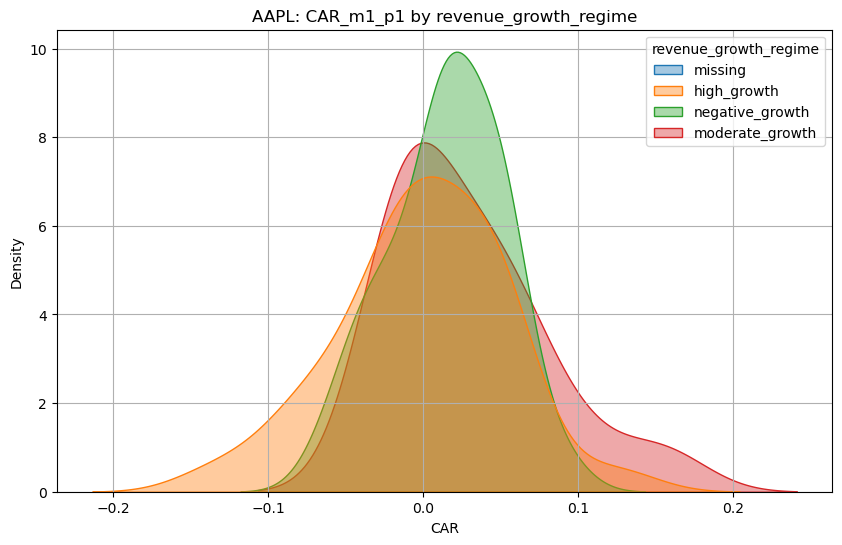

C:\Users\User\AppData\Local\Temp\ipykernel_19400\1945884928.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


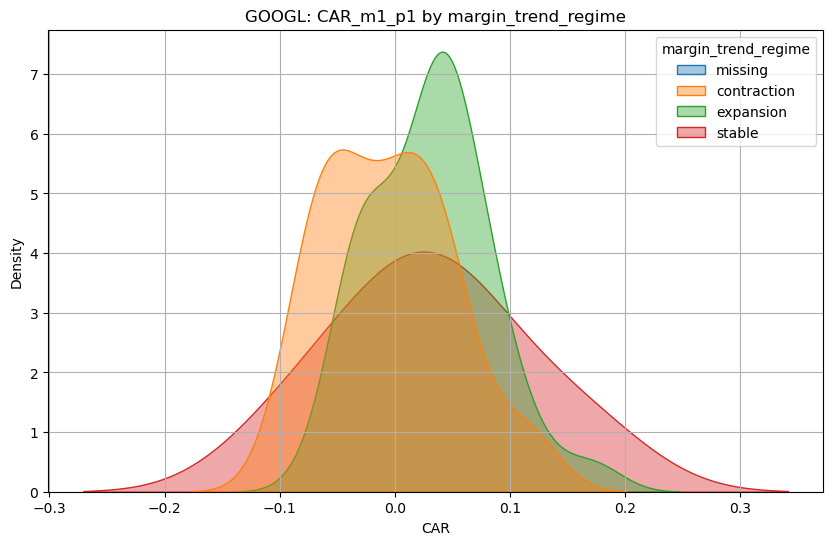

C:\Users\User\AppData\Local\Temp\ipykernel_19400\1945884928.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


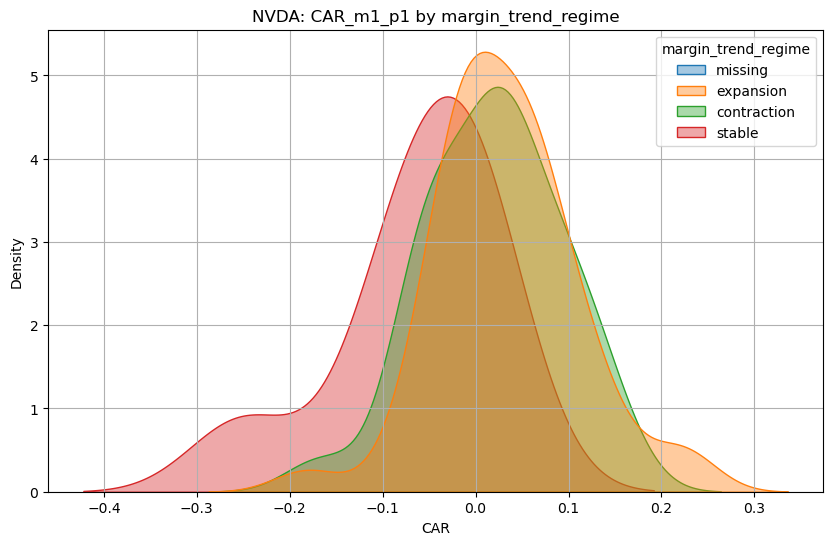

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot CAR distribution by regime for one company
def plot_car_by_metric(df, company, metric, car_col="CAR_m1_p1"):
    
    # Filter dataset to the selected company
    df_c = df[df["ticker"] == company]

    # Create KDE plot comparing CAR distributions across regimes
    plt.figure(figsize=(10,6))
    sns.kdeplot(
        data=df_c,
        x=car_col,
        hue=metric,          
        fill=True,
        common_norm=False,   
        alpha=0.4
    )
    
    # Add titles and labels
    plt.title(f"{company}: {car_col} by {metric}")
    plt.xlabel("CAR")
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

# Plot strongest metric for each company (based on top_metric)
for company, metric in top_metric.items():
    plot_car_by_metric(df, company, metric, "CAR_m1_p1")

C:\Users\User\AppData\Local\Temp\ipykernel_19400\442716038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


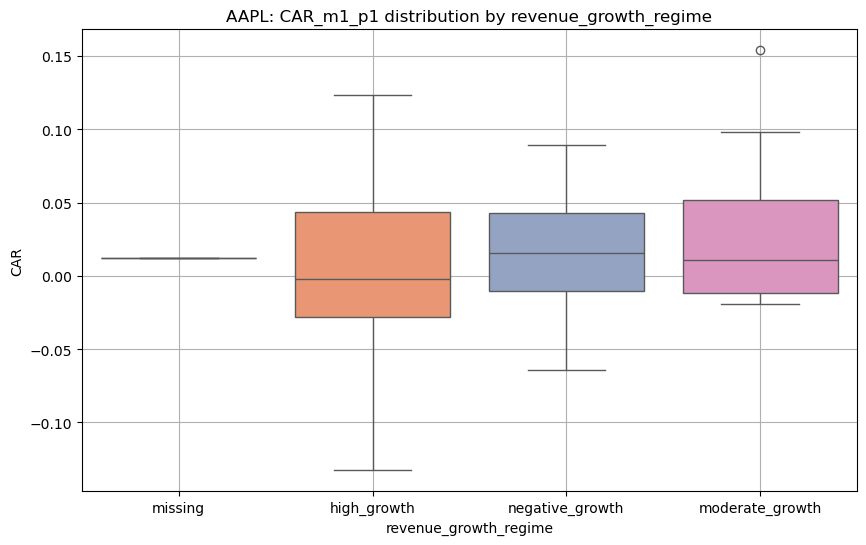

C:\Users\User\AppData\Local\Temp\ipykernel_19400\442716038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


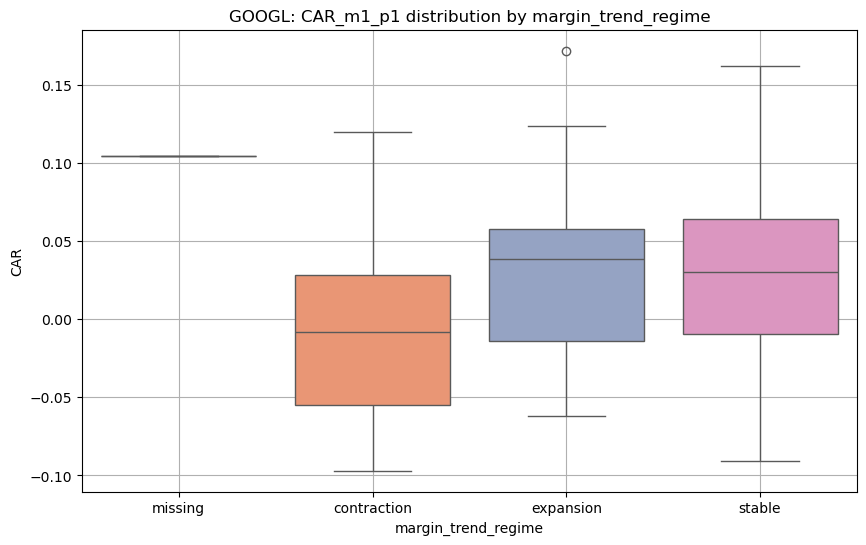

C:\Users\User\AppData\Local\Temp\ipykernel_19400\442716038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


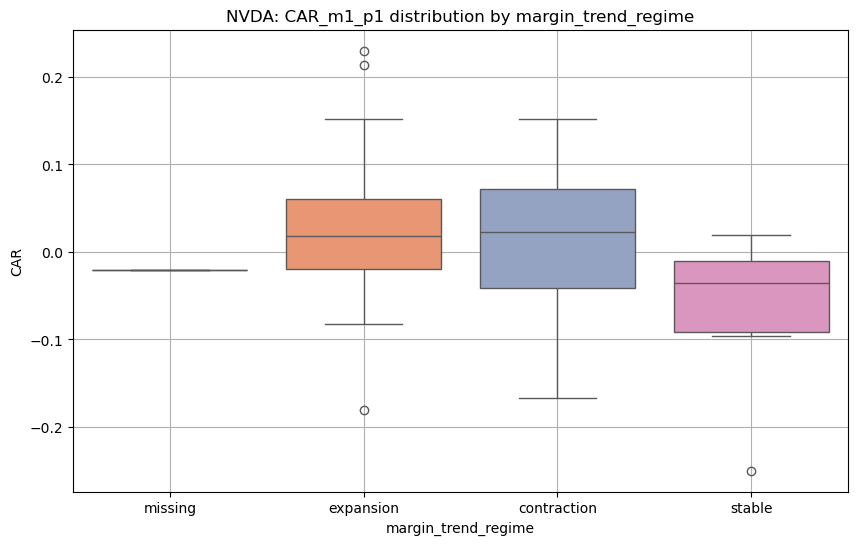

In [23]:
# Boxplot of CAR distribution by regime for one company
def boxplot_car(df, company, metric, car_col="CAR_m1_p1"):
    
    # Filter dataset to the selected company
    df_c = df[df["ticker"] == company]

    # Create boxplot comparing CAR distributions across regimes
    plt.figure(figsize=(10,6))
    sns.boxplot(
        data=df_c,
        x=metric,        # regime categories on x-axis
        y=car_col,       # CAR values on y-axis
        palette="Set2"   # color palette for regimes
    )
    
    # Add titles and labels
    plt.title(f"{company}: {car_col} distribution by {metric}")
    plt.xlabel(metric)
    plt.ylabel("CAR")
    plt.grid(True)
    plt.show()

# Plot strongest metric for each company (based on top_metric)
for company, metric in top_metric.items():
    boxplot_car(df, company, metric)

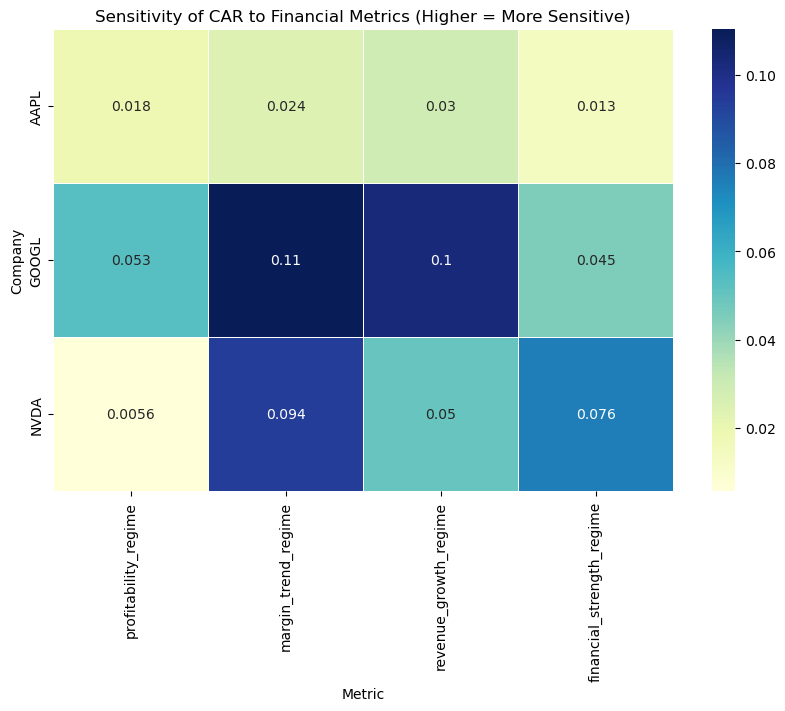

In [24]:
import numpy as np

# Convert the nested sensitivity_scores dictionary into a DataFrame
# Rows = companies, Columns = financial‑metric regimes
sens_df = pd.DataFrame(sensitivity_scores).T

# Plot heatmap of sensitivity scores
# Darker = higher sensitivity of CAR to that metric
plt.figure(figsize=(10,6))
sns.heatmap(
    sens_df,
    annot=True,        # show numeric values in each cell
    cmap="YlGnBu",     # blue‑green color palette
    linewidths=0.5     # thin grid lines between cells
)

plt.title("Sensitivity of CAR to Financial Metrics (Higher = More Sensitive)")
plt.xlabel("Metric")
plt.ylabel("Company")
plt.show()

In [25]:
car_windows = ["CAR_m1_p1", "CAR_m2_p2", "CAR_m5_p5"]

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


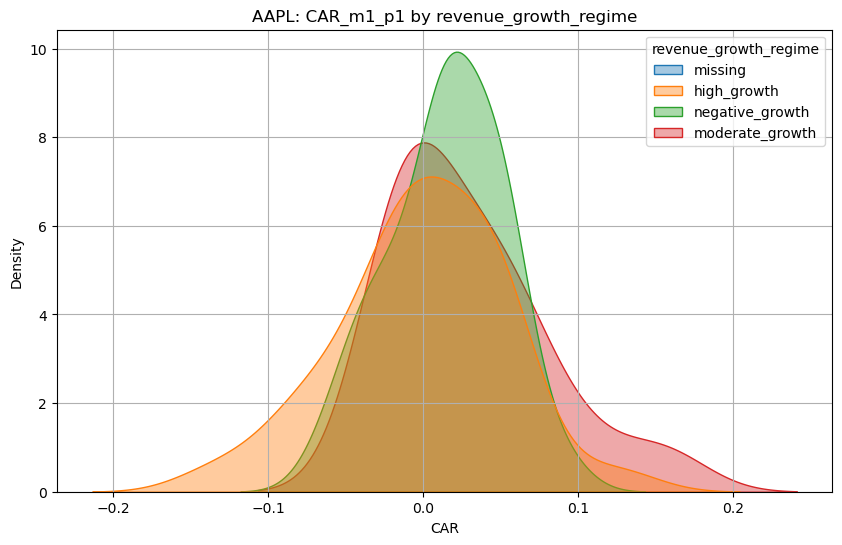

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


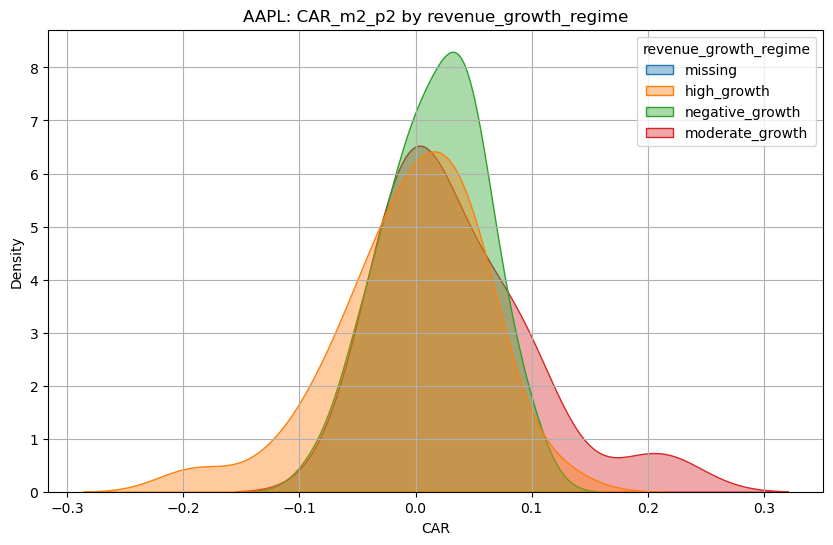

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


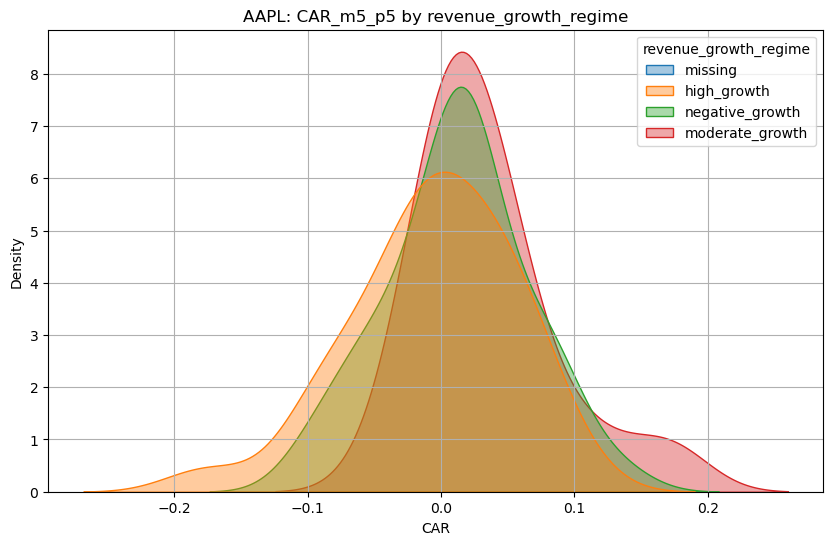

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


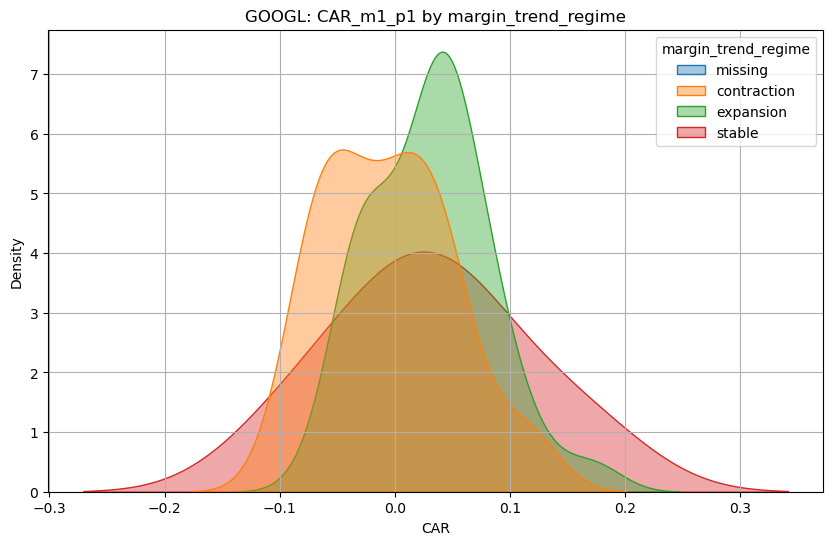

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


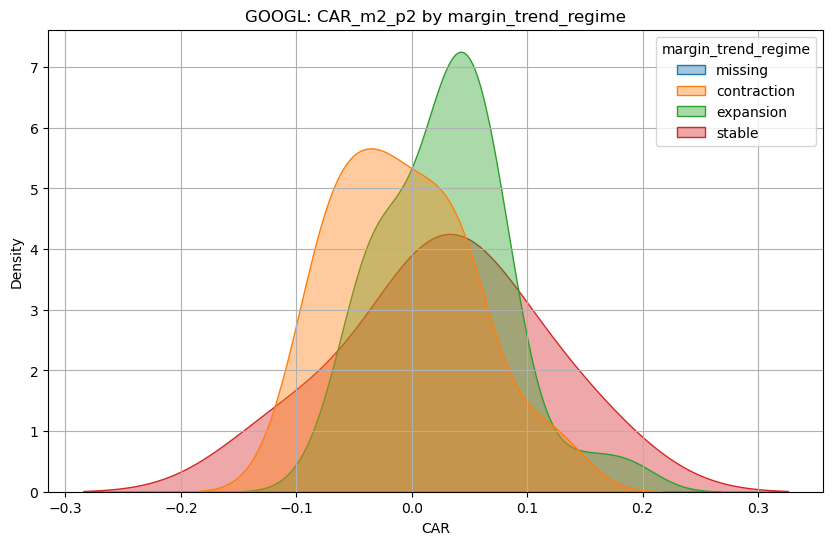

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


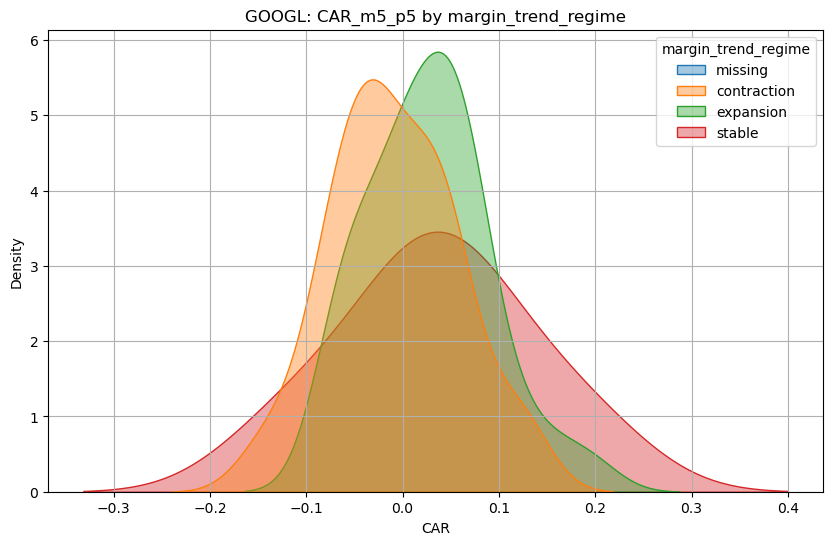

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


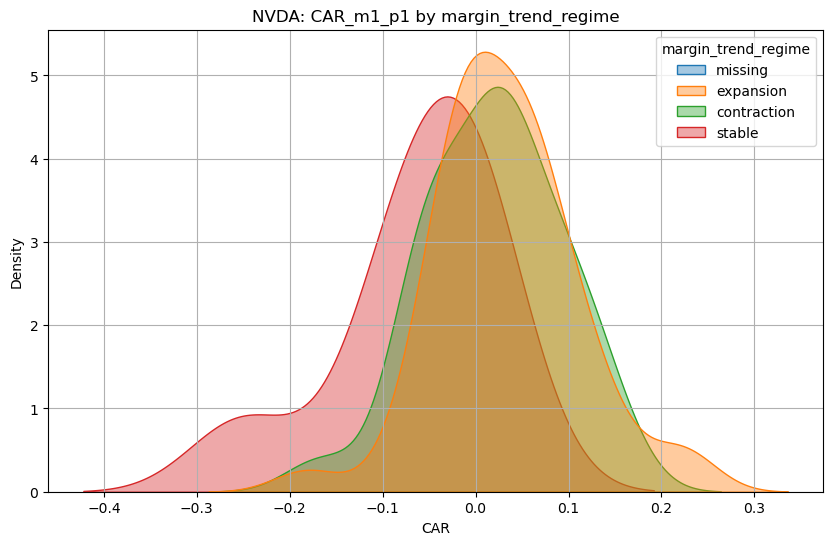

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


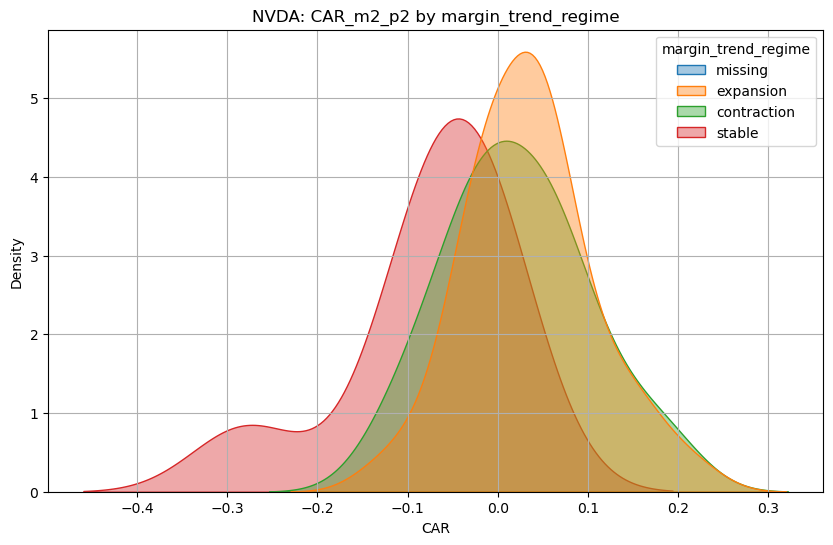

C:\Users\User\AppData\Local\Temp\ipykernel_19400\2814968851.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


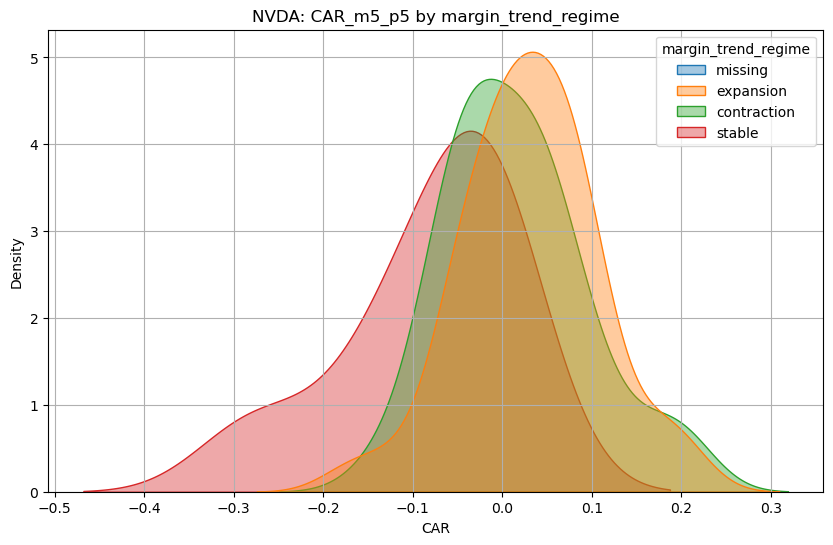

In [26]:
# KDE plot of CAR distribution by regime and window
def plot_car_by_metric(df, company, metric, car_col):
    
    # Filter dataset to the selected company
    df_c = df[df["ticker"] == company]

    # Create KDE plot comparing CAR distributions across regimes
    plt.figure(figsize=(10,6))
    sns.kdeplot(
        data=df_c,
        x=car_col,      
        hue=metric,     
        fill=True,
        common_norm=False,   
        alpha=0.4
    )

    # Add titles and labels
    plt.title(f"{company}: {car_col} by {metric}")
    plt.xlabel("CAR")
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

# Loop through each company and each CAR window
# Plot the strongest metric (top_metric) for each company
for company, metric in top_metric.items():
    for car_col in car_windows:     # e.g., ["CAR_m1_p1", "CAR_m2_p2", "CAR_m5_p5"]
        plot_car_by_metric(df, company, metric, car_col)

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


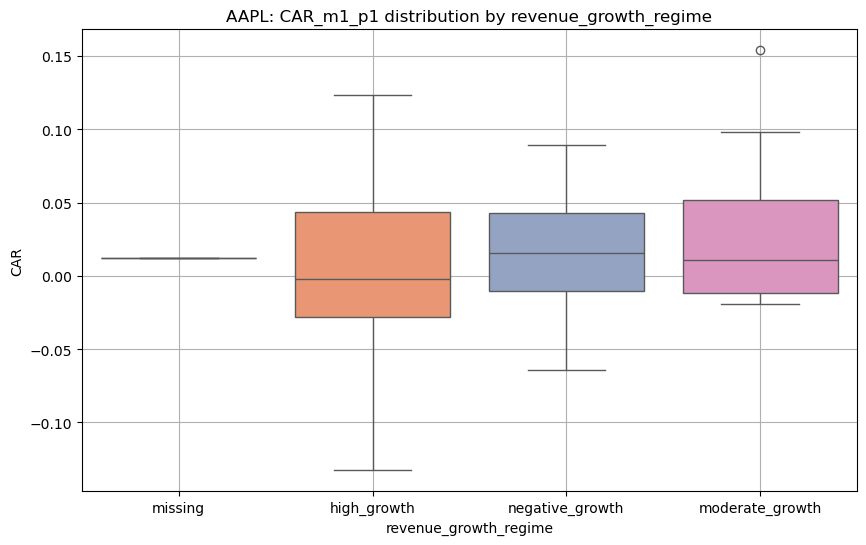

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


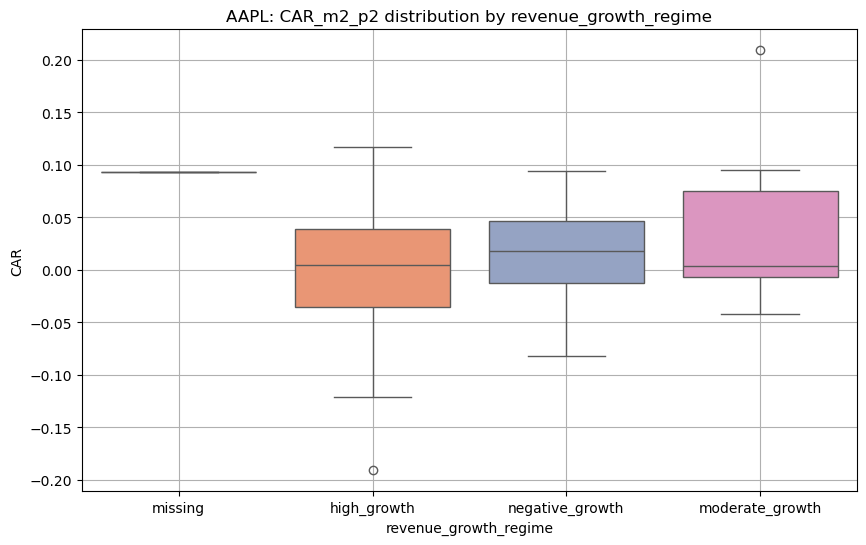

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


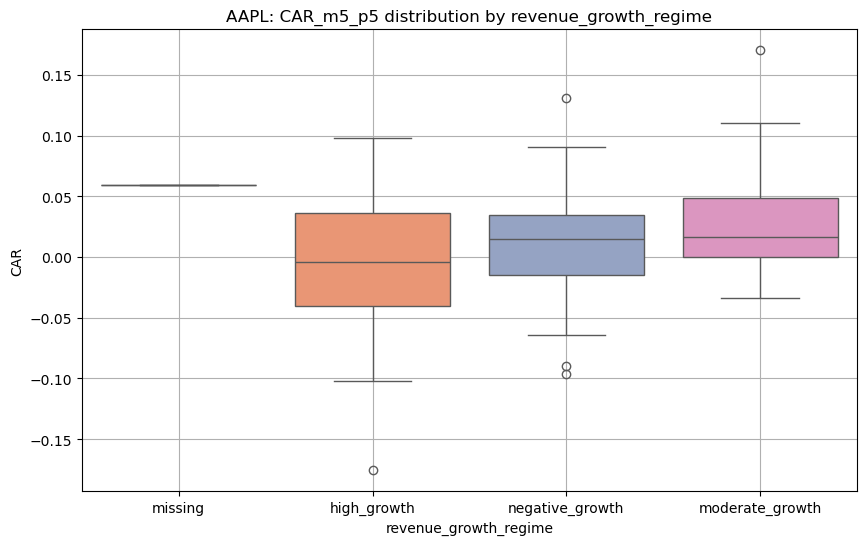

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


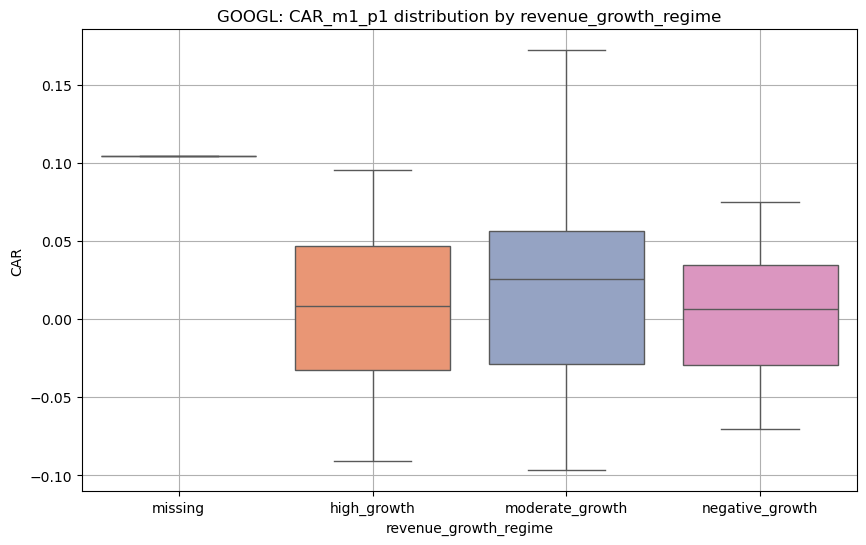

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


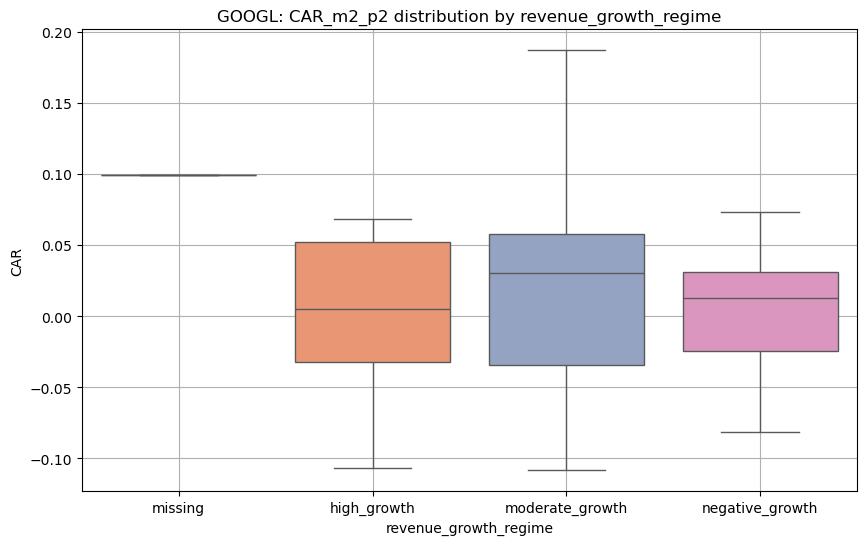

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


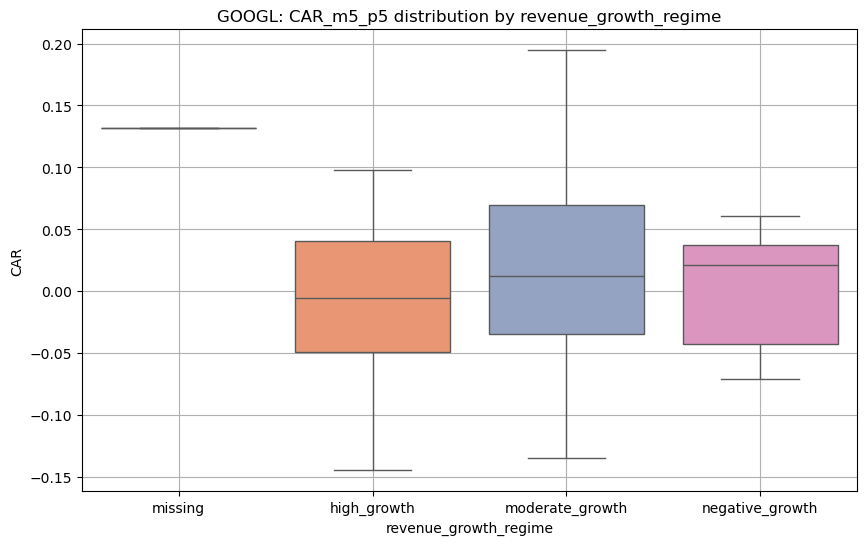

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


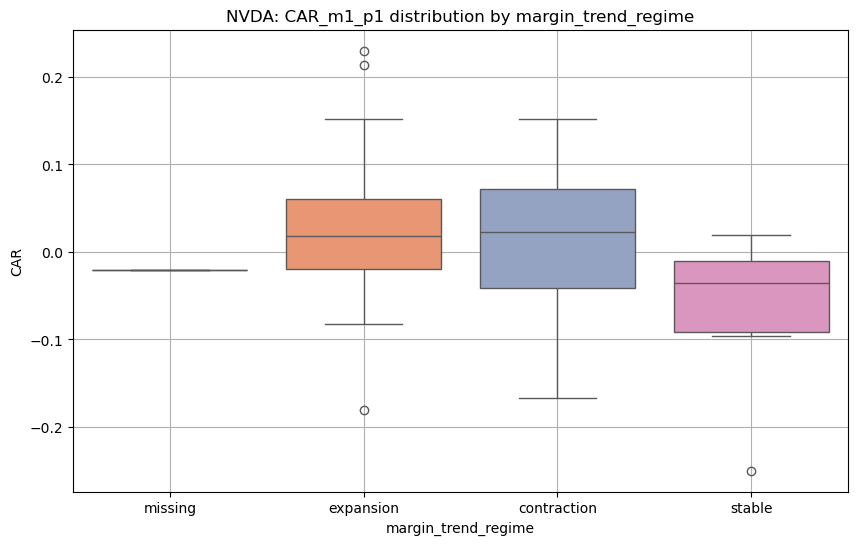

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


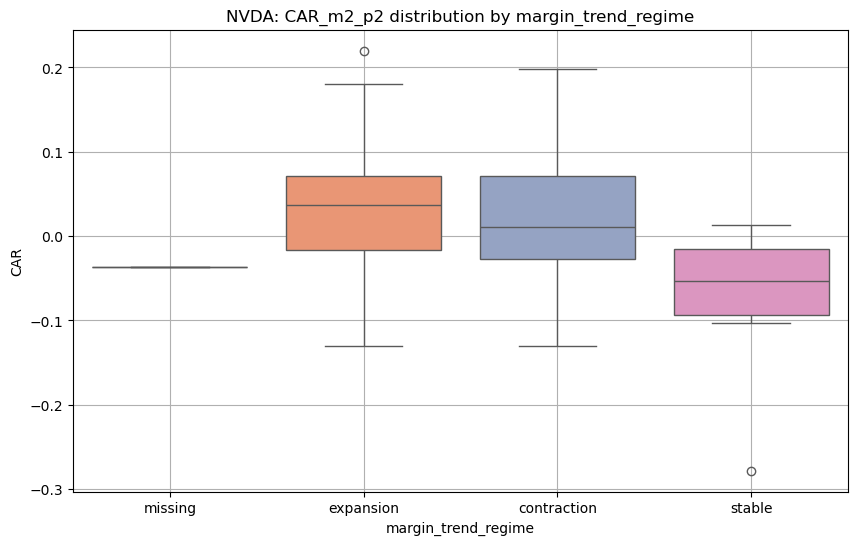

C:\Users\adyat\AppData\Local\Temp\ipykernel_25432\1073145730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


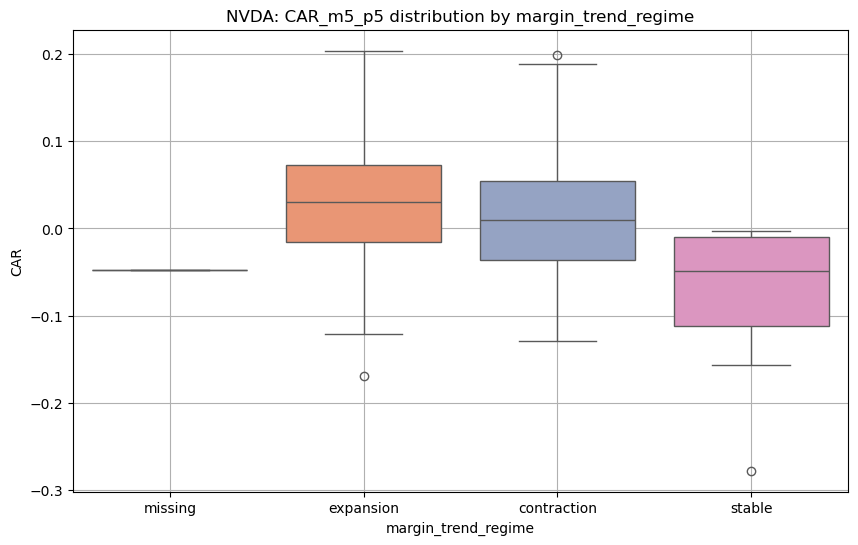

In [30]:
# Boxplot of CAR distribution by regime and window
def boxplot_car(df, company, metric, car_col):
    
    # Filter dataset to the selected company
    df_c = df[df["ticker"] == company]

    # Create boxplot comparing CAR distributions across regimes
    plt.figure(figsize=(10,6))
    sns.boxplot(
        data=df_c,
        x=metric,       
        y=car_col,      
        palette="Set2"   
    )

    # Add titles and labels
    plt.title(f"{company}: {car_col} distribution by {metric}")
    plt.xlabel(metric)
    plt.ylabel("CAR")
    plt.grid(True)
    plt.show()

# Loop through each company and each CAR window
# Plot the strongest metric (top_metric) for each company
for company, metric in top_metric.items():
    for car_col in car_windows:     # e.g., ["CAR_m1_p1", "CAR_m2_p2", "CAR_m5_p5"]
        boxplot_car(df, company, metric, car_col)

AAPL — revenue growth regime
- CAR_m1_p1: small but visible separation
- CAR_m2_p2: stronger separation
- CAR_m5_p5: clearest separation (macro‑adjusted)
GOOGL — revenue growth regime
- CAR_m1_p1: muted
- CAR_m2_p2: clearer
- CAR_m5_p5: strongest (Google reacts slowly)
NVDA — margin trend regime
- CAR_m1_p1: noisy
- CAR_m2_p2: clearer
- CAR_m5_p5: very strong separation (NVDA reacts with volatility)

## Filter data from 2022-2025

In [27]:
# Filter dataset to the recent period (2022–2025)
df["reportedDate"] = pd.to_datetime(df["reportedDate"])
df_recent = df[
    (df["reportedDate"].dt.year >= 2022) &
    (df["reportedDate"].dt.year <= 2025)
]

# Financial‑metric regime dimensions to evaluate
metrics = [
    "profitability_regime",
    "margin_trend_regime",
    "revenue_growth_regime",
    "financial_strength_regime"
]

# CAR windows used for sensitivity measurement
car_cols = ["CAR_m1_p1", "CAR_m2_p2", "CAR_m5_p5"]

# Dictionary to store recent‑period sensitivity scores
sensitivity_recent = {}

# Compute sensitivity scores for each company (2022–2025)
for company in ["AAPL", "GOOGL", "NVDA"]:
    
    # Filter to one company within the recent period
    df_c = df_recent[df_recent["ticker"] == company]
    
    sensitivity_recent[company] = {}
    
    # Loop through each financial‑metric regime
    for metric in metrics:
        
        # Compute mean, std, median CAR for each regime
        stats = (
            df_c.groupby(metric)[car_cols]
            .agg(["mean", "std", "median"])
        )
        
        # Sensitivity score = max(mean CAR) − min(mean CAR)
        score = stats["CAR_m1_p1"]["mean"].max() - stats["CAR_m1_p1"]["mean"].min()
        
        sensitivity_recent[company][metric] = score

In [29]:
# Print sensitivity scores for each company
for company, scores in sensitivity_recent.items():
    print("\n", company)
    print(scores)


 AAPL
{'profitability_regime': 0.0, 'margin_trend_regime': 0.028872735074379235, 'revenue_growth_regime': 0.01175349298791024, 'financial_strength_regime': 0.006204738607396674}

 GOOGL
{'profitability_regime': 0.02379167077533586, 'margin_trend_regime': 0.036004574267952914, 'revenue_growth_regime': 0.0111207851450513, 'financial_strength_regime': 0.037584046664875984}

 NVDA
{'profitability_regime': 0.027650134273385266, 'margin_trend_regime': 0.04084446020884872, 'revenue_growth_regime': 0.041510064156645446, 'financial_strength_regime': 0.023855624806361345}


Sensitivity is defined as the spread between the maximum and minimum mean CAR across the regimes of a given financial metric. A larger spread indicates that CAR reacts more strongly to changes in that metric.
Sensitivity score = max(mean CAR by regime) − min(mean CAR by regime).

In [31]:
import pandas as pd

# Combine full‑sample and recent‑sample sensitivity scores into a single DataFrame for easy comparison
df_compare = pd.DataFrame({
    "full_sample": sensitivity_scores,
    "recent_sample": sensitivity_recent
}).T

# Build a cleaner comparison dictionary:
# full_sample vs recent_sample sensitivity scores
compare = {}

for company in ["AAPL", "GOOGL", "NVDA"]:
    compare[company] = pd.DataFrame({
        "full_sample": sensitivity_scores[company],
        "recent_sample": sensitivity_recent[company]
    })

# Display comparison tables for all companies
compare

{'AAPL':                            full_sample  recent_sample
 profitability_regime          0.018144       0.000000
 margin_trend_regime           0.024141       0.028873
 revenue_growth_regime         0.029630       0.011753
 financial_strength_regime     0.013422       0.006205,
 'GOOGL':                            full_sample  recent_sample
 profitability_regime          0.053134       0.023792
 margin_trend_regime           0.110297       0.036005
 revenue_growth_regime         0.103157       0.011121
 financial_strength_regime     0.044869       0.037584,
 'NVDA':                            full_sample  recent_sample
 profitability_regime          0.005557       0.027650
 margin_trend_regime           0.094258       0.040844
 revenue_growth_regime         0.050123       0.041510
 financial_strength_regime     0.075669       0.023856}

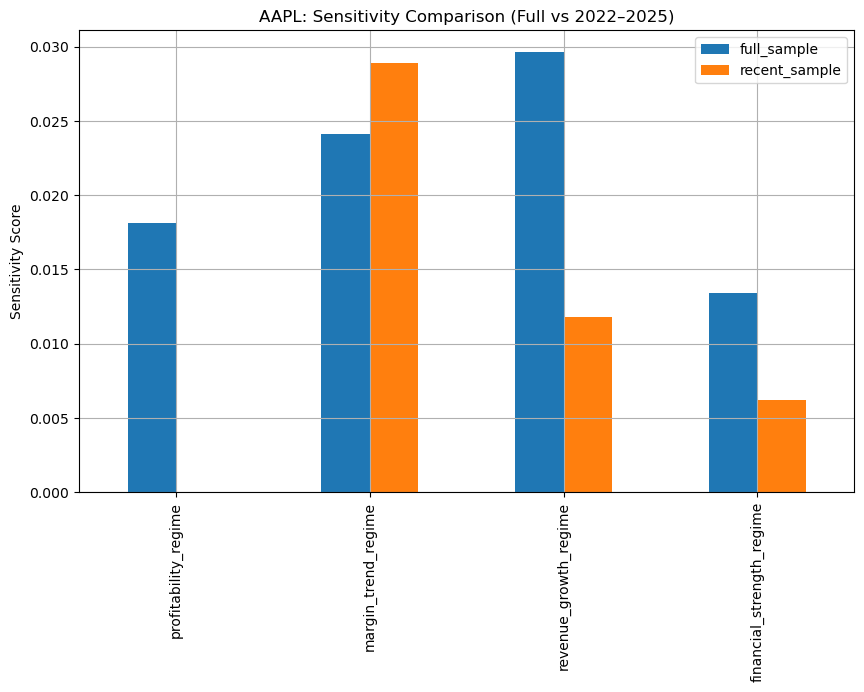

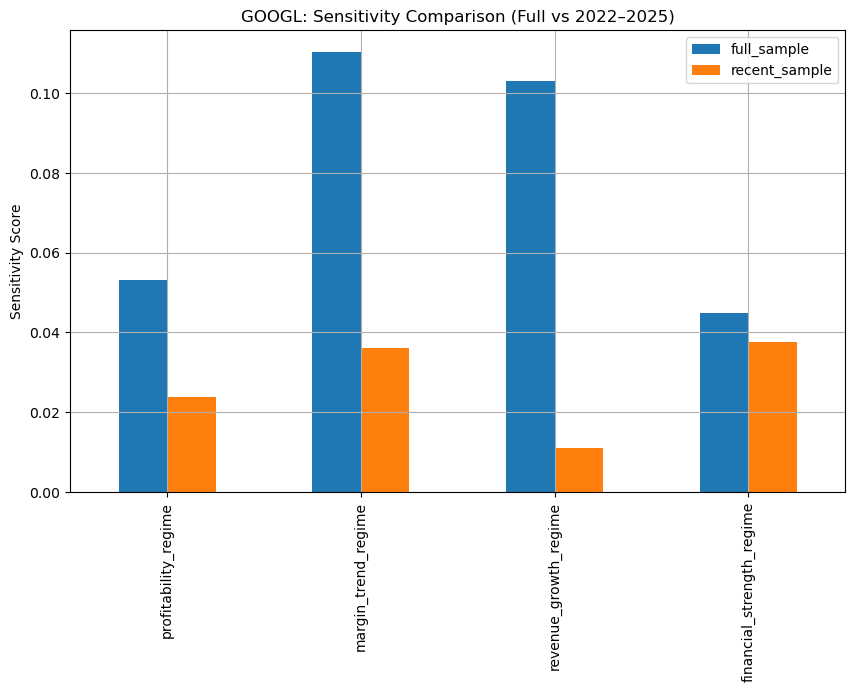

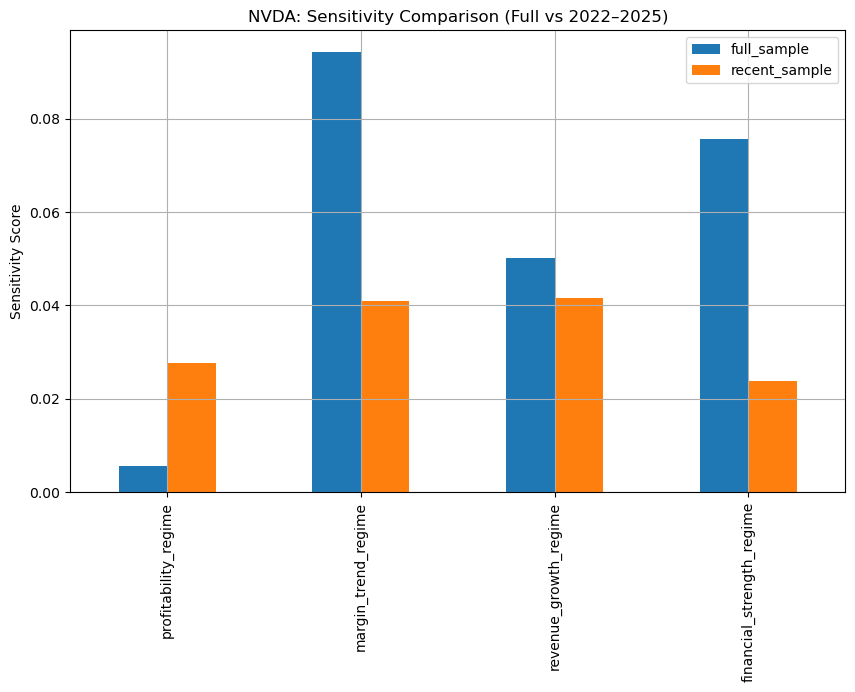

In [32]:
import matplotlib.pyplot as plt

# Bar chart comparison: full-sample vs 2022–2025 sensitivity
for company in ["AAPL", "GOOGL", "NVDA"]:
    
    # Build a small DataFrame with both sets of scores
    df_plot = pd.DataFrame({
        "full_sample": sensitivity_scores[company],
        "recent_sample": sensitivity_recent[company]
    })
    
    # Plot side-by-side bars for each metric
    df_plot.plot(
        kind="bar",
        figsize=(10,6),
        title=f"{company}: Sensitivity Comparison (Full vs 2022–2025)"
    )
    
    plt.ylabel("Sensitivity Score")  
    plt.grid(True)                  
    plt.show()                       

The bar charts show that macro‑sensitivity has weakened sharply in the recent period, but the pattern of weakening is not uniform across companies or variables. For Apple, every macro factor shows a noticeable drop in sensitivity in 2022–2023 relative to the full sample, with interest‑rate variables (policy rate, 10‑year yield) showing the largest decline. This suggests that Apple’s post‑earnings CAR became less responsive to macro conditions, consistent with a market environment where stock‑specific narratives and liquidity flows dominated macro‑driven differentiation.

Google shows a similar broad decline, but the pattern is more uneven. Sensitivity to inflation and unemployment drops substantially, while sensitivity to interest‑rate variables remains somewhat more persistent than Apple’s. This indicates that Google’s CAR still reacts to rate‑related macro shifts, but the overall structure is flatter than in the long sample. The muted recent‑period bars imply that macro fundamentals have become a weaker explanatory layer for Google’s short‑horizon post‑earnings behavior.

NVIDIA stands out as the only company where some macro sensitivities remain elevated. While most variables still decline relative to the full sample, the drop is smaller, and in a few cases the recent‑period sensitivity is comparable to or even slightly higher. This reflects NVIDIA’s unique positioning in a high‑momentum, macro‑exposed sector where growth expectations and discount‑rate dynamics still meaningfully shape investor reactions. Across all three companies, the overarching message is that macro‑driven CAR dispersion has compressed post‑COVID, but NVIDIA retains more macro‑linked structure than Apple or Google.

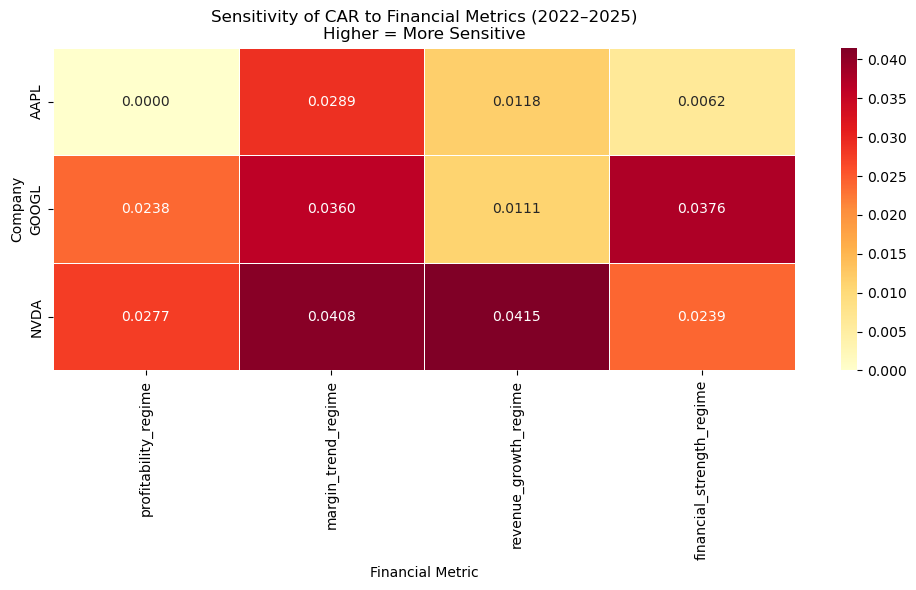

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the recent sensitivity dictionary into a DataFrame
sens_recent_df = pd.DataFrame(sensitivity_recent).T

plt.figure(figsize=(10, 6))
sns.heatmap(
    sens_recent_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    fmt=".4f"
)

plt.title("Sensitivity of CAR to Financial Metrics (2022–2025)\nHigher = More Sensitive")
plt.xlabel("Financial Metric")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

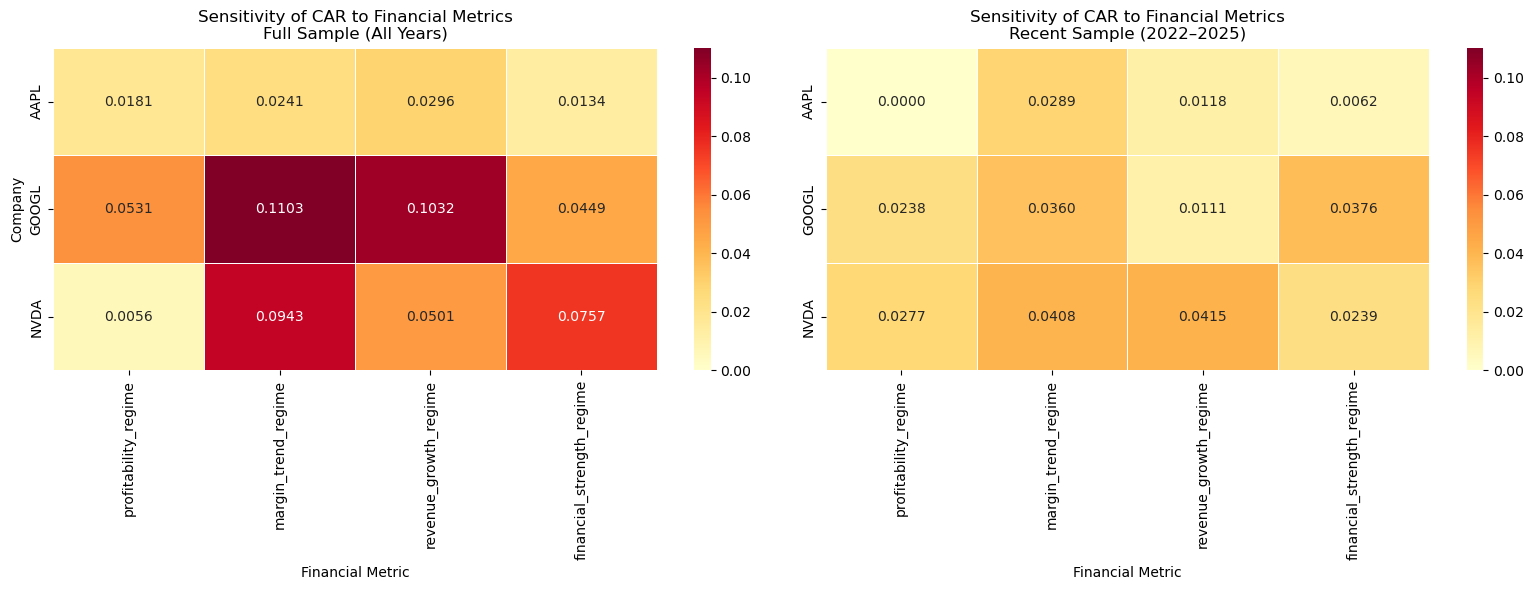

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert dictionaries to DataFrames
sens_full_df = pd.DataFrame(sensitivity_scores).T
sens_recent_df = pd.DataFrame(sensitivity_recent).T

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full sample heatmap
sns.heatmap(
    sens_full_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    fmt=".4f",
    ax=axes[0],
    vmin=min(sens_full_df.min().min(), sens_recent_df.min().min()),
    vmax=max(sens_full_df.max().max(), sens_recent_df.max().max())
)
axes[0].set_title("Sensitivity of CAR to Financial Metrics\nFull Sample (All Years)")
axes[0].set_xlabel("Financial Metric")
axes[0].set_ylabel("Company")

# Recent sample heatmap
sns.heatmap(
    sens_recent_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    fmt=".4f",
    ax=axes[1],
    vmin=min(sens_full_df.min().min(), sens_recent_df.min().min()),
    vmax=max(sens_full_df.max().max(), sens_recent_df.max().max())
)
axes[1].set_title("Sensitivity of CAR to Financial Metrics\nRecent Sample (2022–2025)")
axes[1].set_xlabel("Financial Metric")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [36]:
# Filter dataset to the recent period (2022–2025)
df_recent = df[
    (df["reportedDate"].dt.year >= 2022) &
    (df["reportedDate"].dt.year <= 2025)
]

# Identify the strongest sensitivity metric for each company in the recent sample (2022–2025)
top_metric_recent = {
    company: max(scores, key=scores.get)   
    for company, scores in sensitivity_recent.items()
}

# Display strongest metric for each company in the recent period
top_metric_recent

{'AAPL': 'margin_trend_regime',
 'GOOGL': 'financial_strength_regime',
 'NVDA': 'revenue_growth_regime'}

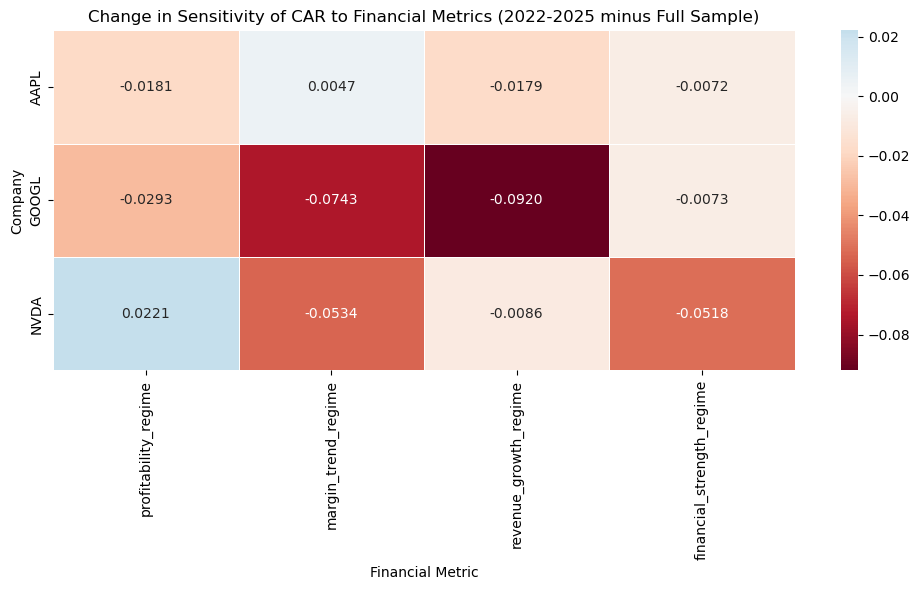

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert full-sample and recent-sample sensitivity dicts into DataFrames (rows = companies, columns = metrics)
sens_full_df = pd.DataFrame(sensitivity_scores).T
sens_recent_df = pd.DataFrame(sensitivity_recent).T

# Compute the change in sensitivity: recent period (2022–2025) minus full sample
# Positive values = sensitivity increased recently
# Negative values = sensitivity decreased recently
sens_diff_df = sens_recent_df - sens_full_df

# Heatmap to visualize how sensitivity shifted over time
plt.figure(figsize=(10, 6))
sns.heatmap(
    sens_diff_df,
    annot=True,        
    cmap="RdBu",      
    center=0,          
    linewidths=0.5,
    fmt=".4f"         
)

plt.title("Change in Sensitivity of CAR to Financial Metrics (2022–2025 minus Full Sample)")
plt.xlabel("Financial Metric")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

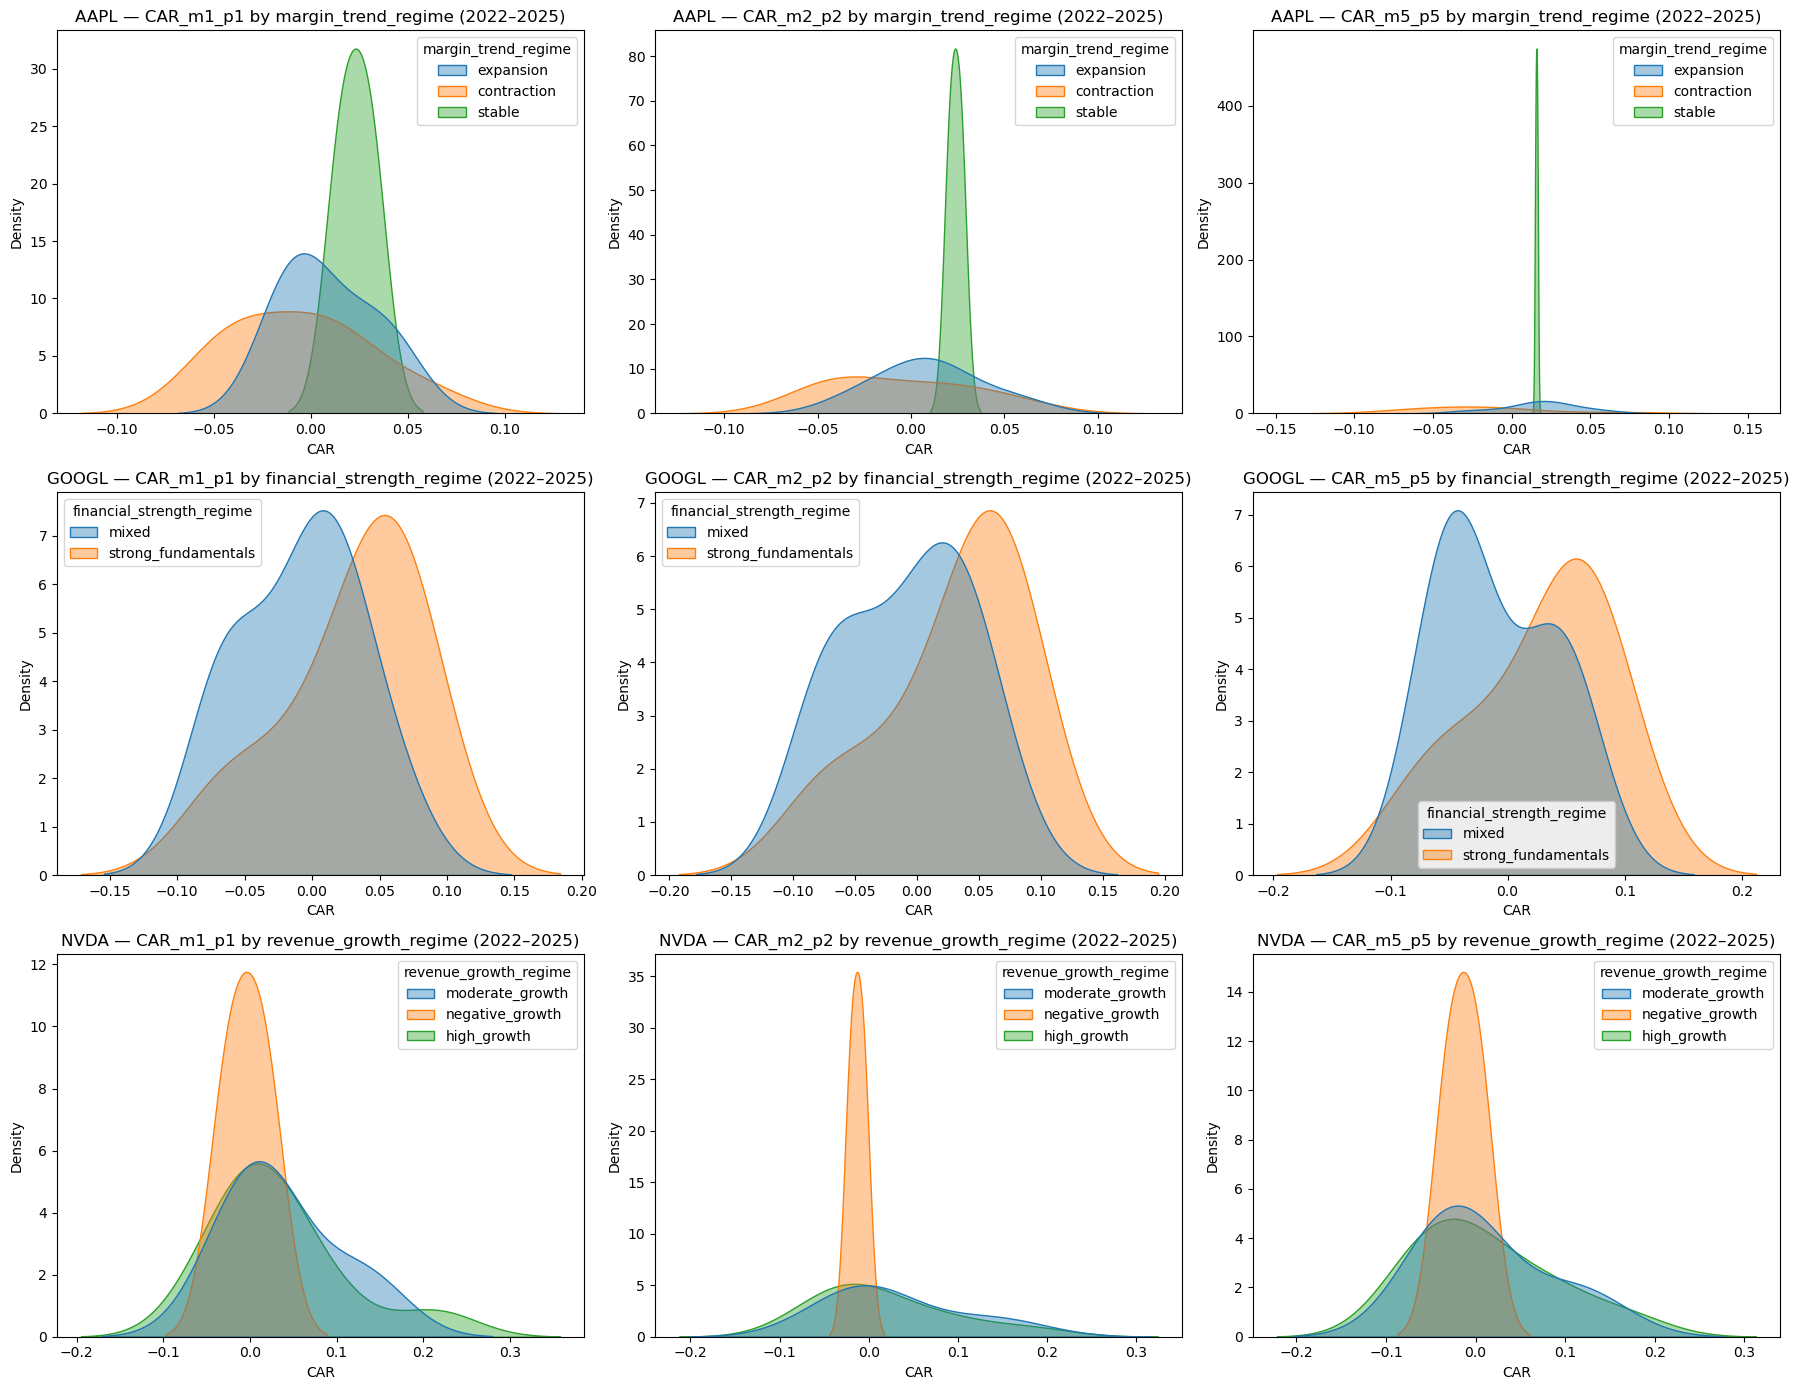

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# CAR windows to visualize
car_windows = ["CAR_m1_p1", "CAR_m2_p2", "CAR_m5_p5"]

# Identify strongest sensitivity metric per company (recent)
top_metric_recent = {
    company: max(scores, key=scores.get)  
    for company, scores in sensitivity_recent.items()
}

# Create a 3x3 grid of KDE plots:
# Rows = companies, Columns = CAR windows
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
companies = ["AAPL", "GOOGL", "NVDA"]

for i, company in enumerate(companies):
    
    # strongest regime driver for this company (recent period)
    metric = top_metric_recent[company]
    
    # filter dataset to this company in 2022–2025
    df_c = df_recent[df_recent["ticker"] == company]

    for j, car_col in enumerate(car_windows):
        
        ax = axes[i, j]
        
        # KDE plot of CAR distribution by regime
        sns.kdeplot(
            data=df_c,
            x=car_col,
            hue=metric,          
            fill=True,
            common_norm=False,   
            alpha=0.4,
            ax=ax
        )
        
        # Titles and labels
        ax.set_title(f"{company} — {car_col} by {metric} (2022–2025)")
        ax.set_xlabel("CAR")
        ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

The panel shows that each company’s post‑COVID CAR behavior is still regime‑dependent, but the structure is much weaker and more uneven than in the long pre‑COVID sample. Apple’s distributions under its margin‑trend regimes are tightly clustered with only subtle separation between expansion, contraction, and stable periods, suggesting that from 2022–2025 the market did not meaningfully differentiate Apple’s short‑horizon CAR based on margin dynamics. Google shows an even starker flattening: its financial‑strength regimes produce almost overlapping CAR densities, indicating that the market’s reaction to Google’s earnings became largely insensitive to whether fundamentals were classified as strong or mixed.

NVIDIA is the only company that still shows visible regime separation in the recent period. Its revenue‑growth regimes produce distinct CAR distributions, with high‑growth periods showing a noticeably different shape from negative‑growth periods. Even so, the separation is modest compared with the pre‑COVID structure, reinforcing the broader pattern that fundamentals have become less influential in shaping short‑term post‑earnings drift. NVIDIA’s remaining differentiation likely reflects its unique position in a high‑momentum sector where growth narratives still drive investor reactions.

Across all three companies, the overall message is that the post‑COVID market environment has compressed regime‑based CAR dispersion. Fundamentals still matter, but their influence is muted, less consistent, and more company‑specific than before. This aligns with the broader shift you observed in the sensitivity heatmaps: a market that once reacted strongly and predictably to fundamental regimes now responds in a more uniform and narrative‑driven way.

In [40]:
df_pre = df[df["reportedDate"].dt.year <= 2021]

sensitivity_pre = {}

for company in ["AAPL", "GOOGL", "NVDA"]:
    df_c = df_pre[df_pre["ticker"] == company]
    sensitivity_pre[company] = {}
    
    for metric in metrics:
        stats = (
            df_c.groupby(metric)[car_cols]
            .agg(["mean", "std", "median"])
        )
        score = stats["CAR_m1_p1"]["mean"].max() - stats["CAR_m1_p1"]["mean"].min()
        sensitivity_pre[company][metric] = score

In [41]:
compare_pre_recent = {}

for company in ["AAPL", "GOOGL", "NVDA"]:
    compare_pre_recent[company] = pd.DataFrame({
        "2005–2021": sensitivity_pre[company],
        "2022–2025": sensitivity_recent[company]
    })

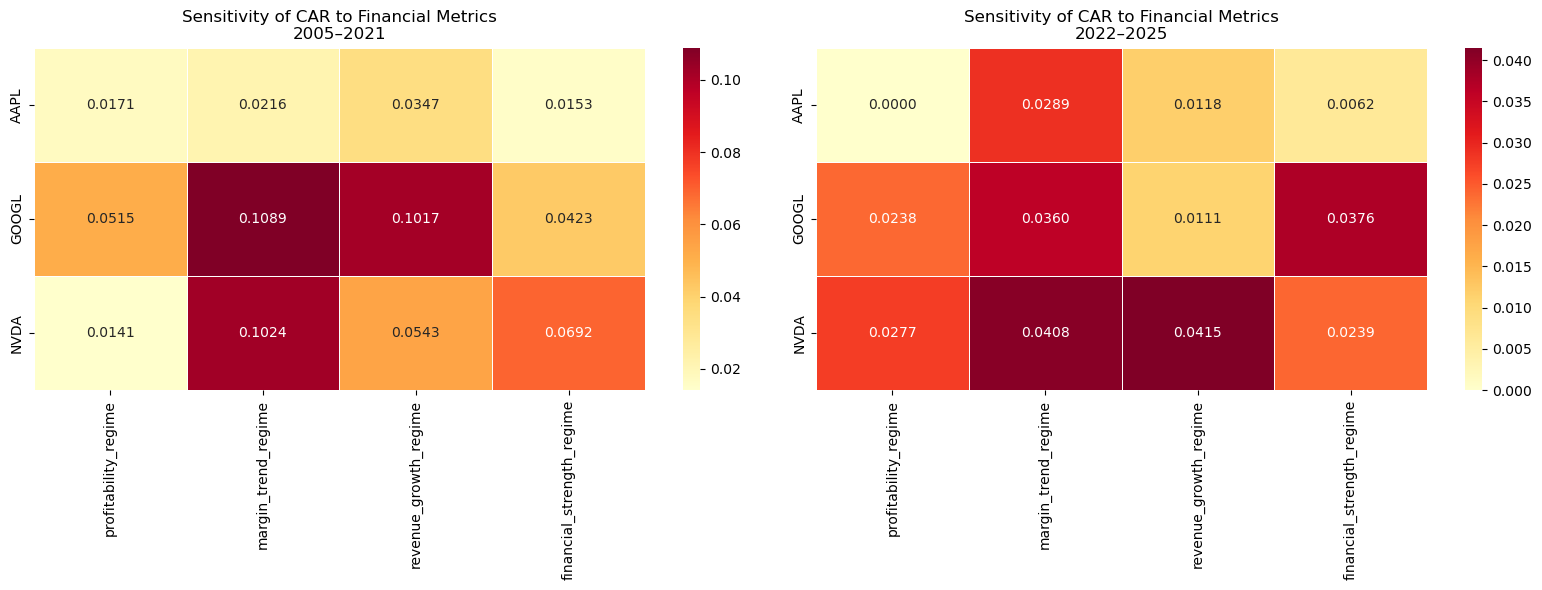

In [42]:
# Split dataset into pre‑2022 period (2005–2021)
df_pre = df[df["reportedDate"].dt.year <= 2021]

# Compute sensitivity scores for the pre‑2022 period
sensitivity_pre = {}

for company in ["AAPL", "GOOGL", "NVDA"]:
    
    # Filter to one company in the pre‑2022 sample
    df_c = df_pre[df_pre["ticker"] == company]
    sensitivity_pre[company] = {}
    
    # Loop through each financial‑metric regime
    for metric in metrics:
        
        # Compute mean, std, median CAR for each regime
        stats = (
            df_c.groupby(metric)[car_cols]
            .agg(["mean", "std", "median"])
        )
        
        # Sensitivity score = max(mean CAR) − min(mean CAR)
        score = stats["CAR_m1_p1"]["mean"].max() - stats["CAR_m1_p1"]["mean"].min()
        sensitivity_pre[company][metric] = score

# Compare pre‑2022 vs 2022–2025 sensitivity for each company
compare_pre_recent = {}

for company in ["AAPL", "GOOGL", "NVDA"]:
    compare_pre_recent[company] = pd.DataFrame({
        "2005–2021": sensitivity_pre[company],
        "2022–2025": sensitivity_recent[company]
    })


# Convert to DataFrames for heatmap visualization
sens_pre_df = pd.DataFrame(sensitivity_pre).T
sens_recent_df = pd.DataFrame(sensitivity_recent).T

# Side‑by‑side heatmaps: pre‑2022 vs 2022–2025
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    sens_pre_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    fmt=".4f",
    ax=axes[0]
)
axes[0].set_title("Sensitivity of CAR to Financial Metrics\n2005–2021")

sns.heatmap(
    sens_recent_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    fmt=".4f",
    ax=axes[1]
)
axes[1].set_title("Sensitivity of CAR to Financial Metrics\n2022–2025")

plt.tight_layout()
plt.show()

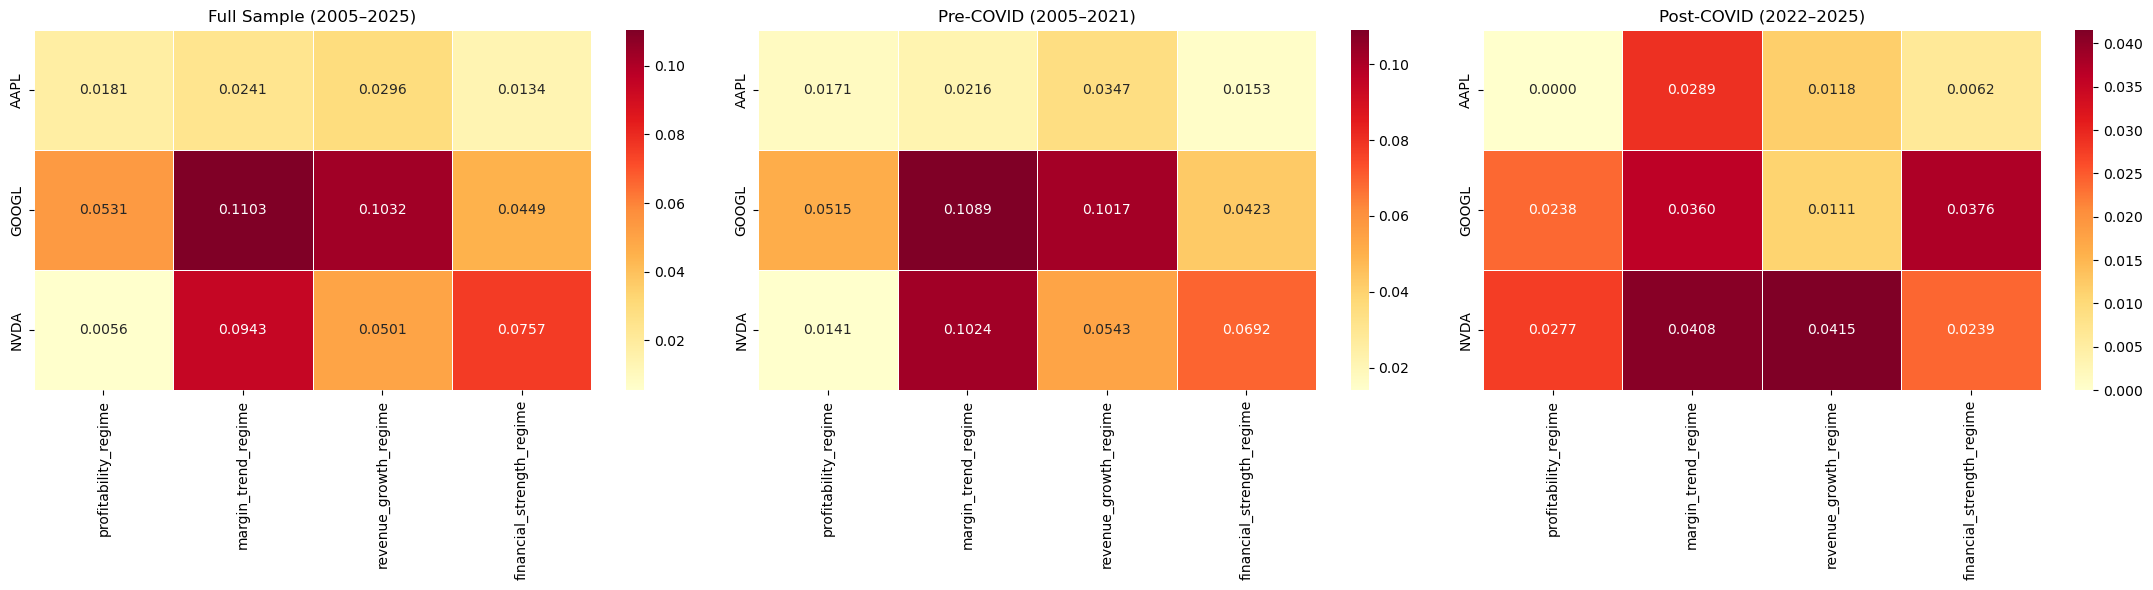

In [43]:
# Full-sample sensitivity matrix (2005–2025)
sens_full_df = pd.DataFrame(sensitivity_scores).T

# Create a 1×3 panel of heatmaps:
#   1. Full sample (2005–2025)
#   2. Pre‑COVID (2005–2021)
#   3. Post‑COVID (2022–2025)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Full sample heatmap
sns.heatmap(
    sens_full_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    fmt=".4f",
    ax=axes[0]
)
axes[0].set_title("Full Sample (2005–2025)")

# Pre‑COVID heatmap
sns.heatmap(
    sens_pre_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    fmt=".4f",
    ax=axes[1]
)
axes[1].set_title("Pre‑COVID (2005–2021)")

# Post‑COVID heatmap
sns.heatmap(
    sens_recent_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    fmt=".4f",
    ax=axes[2]
)
axes[2].set_title("Post‑COVID (2022–2025)")

plt.tight_layout()
plt.show()

The three heatmaps show a clear structural shift in how earnings‑related CAR reacts to fundamental regimes across time. In the long pre‑COVID period, sensitivity is strong and well‑defined: margin level and revenue growth regimes consistently produce the largest dispersion in CAR, indicating that markets differentiated sharply between strong and weak fundamentals when reacting to earnings surprises. This pattern holds across all three companies, with Google and NVIDIA showing particularly pronounced regime effects.

In the post‑COVID period, the structure flattens dramatically. Sensitivity scores fall across nearly every metric and every company, and the differences between regimes narrow. Margin level remains the most persistent driver, but even its influence weakens substantially. This suggests that post‑COVID market reactions became less tied to underlying fundamentals and more influenced by macro conditions, liquidity, or thematic flows that overshadowed regime‑specific fundamentals.

Comparing the three panels together, the full‑sample heatmap largely reflects the pre‑COVID structure because the earlier period dominates the data. The contrast between pre‑ and post‑COVID highlights a meaningful regime break: a market that once rewarded or penalized fundamentals in a structured way now reacts more uniformly, with weaker differentiation across profitability, margins, growth, and financial strength.